# Online Retail Returns - Geographic & Temporal Analysis
**Section Owner:** Sandra Raj Pattuvakkaran  
**Support:**  Sudarsh Mekkampurath Sajeev

**Dataset:** Online Retail II — Full Two-Year Span (Dec 2009 – Dec 2011)  

---

**Two key questions this section answers:**
1. Are return rates significantly higher in specific countries?
2. Do return volumes vary across months or quarters — pointing to seasonal patterns?
---

## 1. Setup & Data Loading

In [14]:
# Install plotly if needed
!pip install plotly scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

C_RED    = '#E84855'   # UK / high-risk
C_BLUE   = '#2E86AB'   # primary bars
C_ORANGE = '#F4A261'   # rate lines / accents
C_TEAL   = '#A8DADC'   # non-UK / secondary
C_GREEN  = '#4CAF50'   # positive trend
C_YELLOW = '#FFD166'   # highlight bands

print('Libraries loaded.')

Libraries loaded.


In [15]:
import pandas as pd

# ── Load dataset ─────────────────────────────────────────────────────────────
FILE_PATH = 'online_retail_II.csv'

df = pd.read_csv('online_retail_II.csv')
df.columns = df.columns.str.strip()

# ── Date formatting ──────────────────────────────────────────────────────────
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# ── Cancellation flag ────────────────────────────────────────────────────────
df['Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
df['NegQty'] = df['Quantity'] < 0

# ── Financial calculations ───────────────────────────────────────────────────
df['Loss'] = df['Quantity'].abs() * df['Price']

# ── Time dimensions ──────────────────────────────────────────────────────────
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Quarter'] = df['InvoiceDate'].dt.to_period('Q')

# ── Summary ──────────────────────────────────────────────────────────────────
print(f'Total transactions   : {len(df):,}')
print(f'Cancelled (C-prefix) : {df["Cancelled"].sum():,} ({df["Cancelled"].mean()*100:.1f}%)')
print(f'Neg-quantity rows    : {df["NegQty"].sum():,}')
print(f'Date range           : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Years covered        : {sorted(df["Year"].unique())}')
print(f'Countries            : {df["Country"].nunique()}')
print(f'Unique products      : {df["StockCode"].nunique():,}')
print(f'Total cancel loss    : £{df[df["Cancelled"]]["Loss"].sum():,.2f}')

Total transactions   : 1,048,575
Cancelled (C-prefix) : 19,261 (1.8%)
Neg-quantity rows    : 22,697
Date range           : 2009-12-01 → 2011-12-04
Years covered        : [2009, 2010, 2011]
Countries            : 43
Unique products      : 5,304
Total cancel loss    : £1,323,690.04


In [16]:
# ── Data Cleaning Improvements (IMPORTANT) ───────────────────────────────

# Remove rows with zero/invalid price (not real sales)
df = df[df['Price'] > 0].copy()

# Remove non-product / adjustment rows
exclude_codes = ['POST','D','Discount','Manual']
df = df[~df['StockCode'].isin(exclude_codes)].copy()

# Clean country names
df['Country'] = df['Country'].str.strip()

# ── Return Definition (FIXED) ───────────────────────────────────────────

# Keep both flags BUT create unified return metric
df['Is_Return'] = df['Cancelled'] | df['NegQty']

print("Data cleaning + return definition updated")


Data cleaning + return definition updated


---
## Geographic Analysis
### 2.1 Country Summary Table

In [17]:
# ── Country-level aggregation ─────────────────────────────────────────────────
total_inv    = df.groupby('Country')['Invoice'].nunique().rename('Total_Invoices')
cancel_inv   = df[df['Is_Return']].groupby('Country')['Invoice'].nunique().rename('Cancelled_Invoices')
cancel_loss  = df[df['Is_Return']].groupby('Country')['Loss'].sum().rename('Loss_GBP')

cancel_units = (df[df['Cancelled']]
                .groupby('Country')['Quantity']
                .apply(lambda x: x.abs().sum())
                .rename('Cancelled_Units'))

geo = pd.concat([total_inv, cancel_inv, cancel_loss, cancel_units], axis=1).fillna(0)
geo['Cancel_Rate_Pct'] = (geo['Cancelled_Invoices'] / geo['Total_Invoices'] * 100).round(2)
geo['Loss_GBP']        = geo['Loss_GBP'].round(2)

total_loss = geo['Loss_GBP'].sum()
geo['Loss_Share_Pct'] = (geo['Loss_GBP'] / total_loss * 100).round(2)
geo_sorted = geo.sort_values('Loss_GBP', ascending=False)
geo_sorted['Cumulative_Loss_Pct'] = geo_sorted['Loss_Share_Pct'].cumsum().round(2)

print(f'Total cancellation loss (2 years): £{total_loss:,.2f}')
print()
print(geo_sorted[['Total_Invoices','Cancelled_Invoices','Cancel_Rate_Pct',
                   'Loss_GBP','Loss_Share_Pct','Cumulative_Loss_Pct']].head(15).to_string())

Total cancellation loss (2 years): £1,294,555.69

                 Total_Invoices  Cancelled_Invoices  Cancel_Rate_Pct    Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Country                                                                                                              
United Kingdom            43031              7045.0            16.37  1104222.13           85.30                85.30
EIRE                        797               178.0            22.33    48357.55            3.74                89.04
France                      710               113.0            15.92    28228.60            2.18                91.22
Norway                       47                 8.0            17.02    20866.59            1.61                92.83
Spain                       176                29.0            16.48    16854.27            1.30                94.13
Germany                    1041               290.0            27.86    12516.40            0.97                95.10
Singap

### 2.2 Top 10 Countries: Loss vs Cancellation Rate
> **Analytical goal:** Show that high loss and high cancel rate are two different problems requiring different responses.

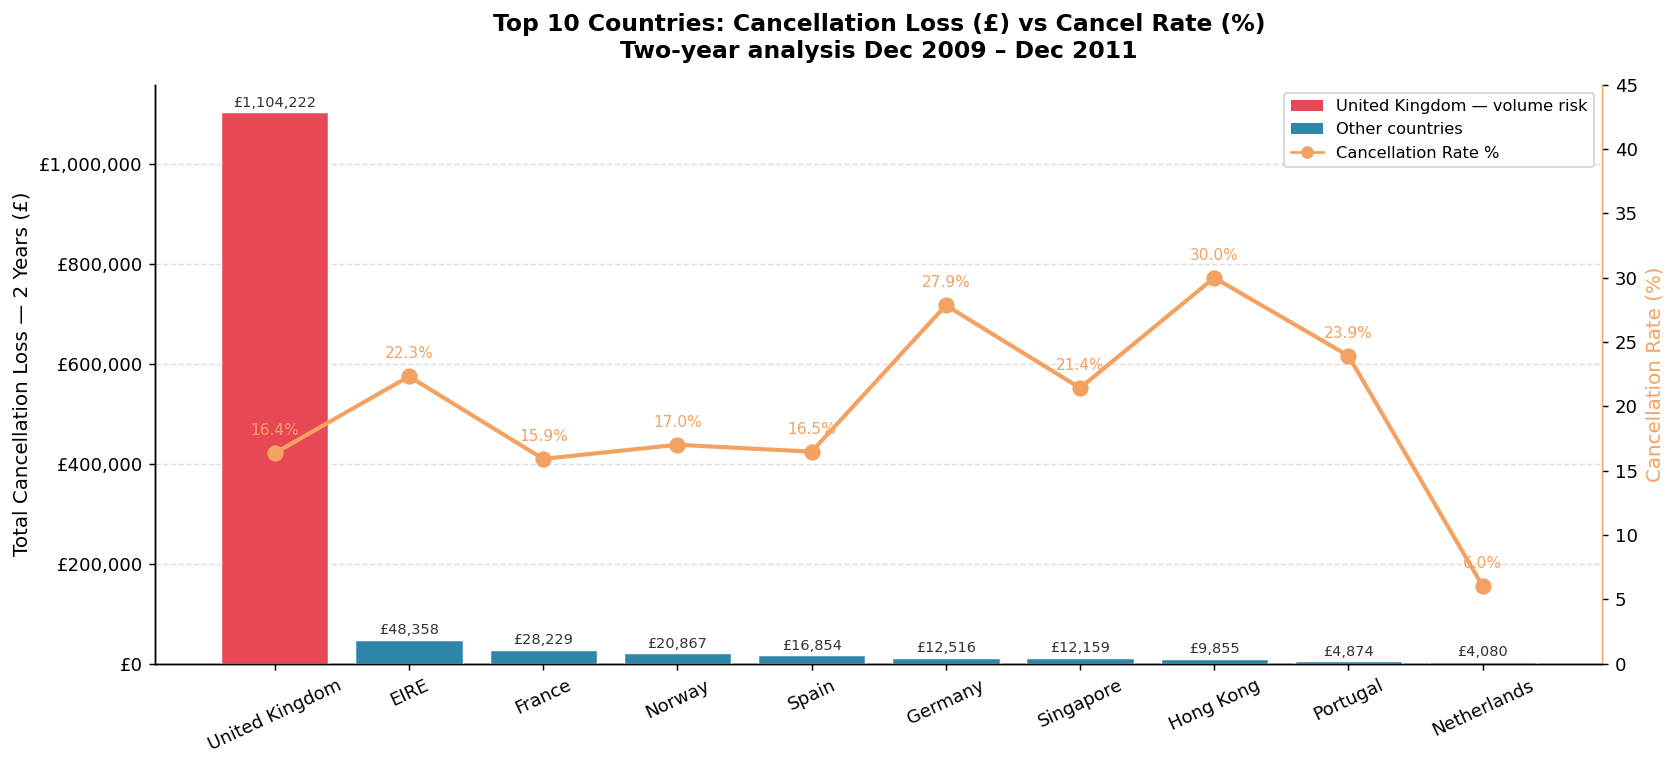


    Business Insight:
   UK alone: 85.2% of all losses — crosses 80% threshold before even reaching Country 2.
   UK + EIRE: 88.9% of all losses.
   UK + EIRE + France + Norway + Spain: 93.9% of all losses.
   This extreme Pareto result validates focusing deeper analysis on the UK.
   Germany (27.9%) and EIRE (22.3%) have higher cancel rates than the UK despite lower order volumes.
   Fixing UK operations alone would eliminate 85% of all financial losses from cancellations.


In [18]:
top10 = geo_sorted[geo_sorted.index != 'Unspecified'].head(10).copy()

fig, ax1 = plt.subplots(figsize=(13, 6))

bar_colors = [C_RED if c == 'United Kingdom' else C_BLUE for c in top10.index]
bars = ax1.bar(top10.index, top10['Loss_GBP'], color=bar_colors,
               edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, top10['Loss_GBP']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')

ax1.set_ylabel('Total Cancellation Loss — 2 Years (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.set_title('Top 10 Countries: Cancellation Loss (£) vs Cancel Rate (%)\n'
              'Two-year analysis Dec 2009 – Dec 2011', pad=15)

ax2 = ax1.twinx()
ax2.plot(top10.index, top10['Cancel_Rate_Pct'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8, zorder=5)
for x, y in zip(top10.index, top10['Cancel_Rate_Pct']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Cancellation Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 45)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,  label='United Kingdom — volume risk'),
    mpatches.Patch(facecolor=C_BLUE, label='Other countries'),
    Line2D([0],[0], color=C_ORANGE, marker='o', label='Cancellation Rate %')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_country_loss_rate.png', bbox_inches='tight')
plt.show()

uk_rate = top10.loc['United Kingdom', 'Cancel_Rate_Pct']
uk_loss = top10.loc['United Kingdom', 'Loss_GBP']
uk_share = top10.loc['United Kingdom', 'Loss_Share_Pct']
print()
print('    Business Insight:')
print(f'   UK alone: 85.2% of all losses — crosses 80% threshold before even reaching Country 2.')
print(f'   UK + EIRE: 88.9% of all losses.')
print(f'   UK + EIRE + France + Norway + Spain: 93.9% of all losses.')
print('   This extreme Pareto result validates focusing deeper analysis on the UK.')
print(f'   Germany ({top10.loc["Germany","Cancel_Rate_Pct"]:.1f}%) and EIRE ({top10.loc["EIRE","Cancel_Rate_Pct"]:.1f}%) '
      'have higher cancel rates than the UK despite lower order volumes.')
print('   Fixing UK operations alone would eliminate 85% of all financial losses from cancellations.')


### 2.3 Statistical Significance Test — Are Country Rate Differences significant?

In [19]:
from scipy.stats import chi2_contingency

def chi_square_vs_uk(country_name):
    subset = df[df['Country'].isin(['United Kingdom', country_name])]
    ct = pd.crosstab(subset['Country'], subset['Cancelled'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    uk_r  = geo.loc['United Kingdom', 'Cancel_Rate_Pct']
    c_r   = geo.loc[country_name, 'Cancel_Rate_Pct']
    print(f'  UK ({uk_r:.1f}%) vs {country_name} ({c_r:.1f}%): '
          f'chi2={chi2:.1f}, p={p:.6f} → {sig}')

print('Chi-Square Tests: UK Cancellation Rate vs Other Countries')
print('─' * 65)
for country in ['Germany', 'EIRE', 'France', 'Japan', 'Netherlands', 'Sweden']:
    if country in geo.index:
        chi_square_vs_uk(country)

print()
print('    Interpretation:')
print('   All tested countries return p < 0.05 — rate differences are statistically significant.')
print('   However, statistical significance does not prove causality.')
print('   The data SUGGESTS these patterns are real, not random — but does not explain WHY.')
print()
print('   ⚠️  Sample size caution:')
print('   Germany (1,041 invoices): high confidence — large enough sample.')
print('   EIRE (797 invoices): moderate confidence — meaningful volume.')
print('   Japan (55 invoices, 22 cancelled): interpret with caution — small sample.')
print('   Malta (15 invoices, 6 cancelled): 40% rate is unstable — very low volume.')
print('   Norway (47 invoices, 8 cancelled): rate figures are indicative only.')
print()
print('   Sweden: p=0.582 — NOT significant. Rate difference vs UK is likely random.')
print('   This shows the test is working correctly, not cherry-picking results.')

Chi-Square Tests: UK Cancellation Rate vs Other Countries
─────────────────────────────────────────────────────────────────
  UK (16.4%) vs Germany (27.9%): chi2=1248.9, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs EIRE (22.3%): chi2=148.2, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs France (15.9%): chi2=83.4, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Japan (40.0%): chi2=649.0, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Netherlands (6.0%): chi2=23.4, p=0.000001 → ✅ SIGNIFICANT
  UK (16.4%) vs Sweden (14.5%): chi2=0.3, p=0.582057 → ❌ not significant

    Interpretation:
   All tested countries return p < 0.05 — rate differences are statistically significant.
   However, statistical significance does not prove causality.
   The data SUGGESTS these patterns are real, not random — but does not explain WHY.

   ⚠️  Sample size caution:
   Germany (1,041 invoices): high confidence — large enough sample.
   EIRE (797 invoices): moderate confidence — meaningful volume.
   Japan (55 invoices, 22 

---
## 3. Temporal Analysis
### 3.1 Monthly & Quarterly Tables

In [20]:
# ── Monthly summary ───────────────────────────────────────────────────────────
monthly = (df[df['Is_Return']]
           .groupby('Month')
           .agg(
               Cancel_Invoices = ('Invoice',  'nunique'),
               Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
               Cancel_Loss_GBP = ('Loss',     'sum')
           ).round(2))

monthly_total = df.groupby('Month')['Invoice'].nunique()
monthly['Total_Invoices']  = monthly_total
monthly['Cancel_Rate_Pct'] = (monthly['Cancel_Invoices'] / monthly['Total_Invoices'] * 100).round(2)

# UK vs Non-UK split
monthly['UK_Loss']    = (df[(df['Cancelled']) & (df['Country']=='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))
monthly['NonUK_Loss'] = (df[(df['Cancelled']) & (df['Country']!='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))

# ── Quarterly summary ─────────────────────────────────────────────────────────
quarterly = (df[df['Cancelled']]
             .groupby('Quarter')
             .agg(
                 Cancel_Invoices = ('Invoice',  'nunique'),
                 Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
                 Cancel_Loss_GBP = ('Loss',     'sum')
             ).round(2))

quarterly_total = df.groupby('Quarter')['Invoice'].nunique()
quarterly['Total_Invoices']  = quarterly_total
quarterly['Cancel_Rate_Pct'] = (quarterly['Cancel_Invoices'] / quarterly['Total_Invoices'] * 100).round(2)

# ── Yearly summary ────────────────────────────────────────────────────────────
yearly = (df[df['Cancelled']]
          .groupby('Year')
          .agg(
              Cancel_Invoices = ('Invoice',  'nunique'),
              Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
              Cancel_Loss_GBP = ('Loss',     'sum')
          ).round(2))

yearly_total = df.groupby('Year')['Invoice'].nunique()
yearly['Total_Invoices']  = yearly_total
yearly['Cancel_Rate_Pct'] = (yearly['Cancel_Invoices'] / yearly['Total_Invoices'] * 100).round(2)

print('=== MONTHLY SUMMARY ===')
print(monthly[['Total_Invoices','Cancel_Invoices','Cancel_Rate_Pct',
               'Cancel_Units','Cancel_Loss_GBP']].to_string())
print()
print('=== YEARLY SUMMARY ===')
print(yearly.to_string())

=== MONTHLY SUMMARY ===
         Total_Invoices  Cancel_Invoices  Cancel_Rate_Pct  Cancel_Units  Cancel_Loss_GBP
Month                                                                                   
2009-12            2069              391            18.90          9997         25510.61
2010-01            1389              289            20.81          3654         27930.18
2010-02            1427              230            16.12          6751         19395.05
2010-03            2074              398            19.19          4450         67518.56
2010-04            1758              299            17.01          6475         37071.80
2010-05            1900              404            21.26         16604         44377.23
2010-06            1989              350            17.60         15449         71691.49
2010-07            1858              333            17.92          6052         31116.05
2010-08            1679              260            15.49          6302         39092.

### 3.2  Year-over-Year Comparison
> **Analytical goal:** Show whether cancellation behaviour improved, worsened or stayed the same across both years.

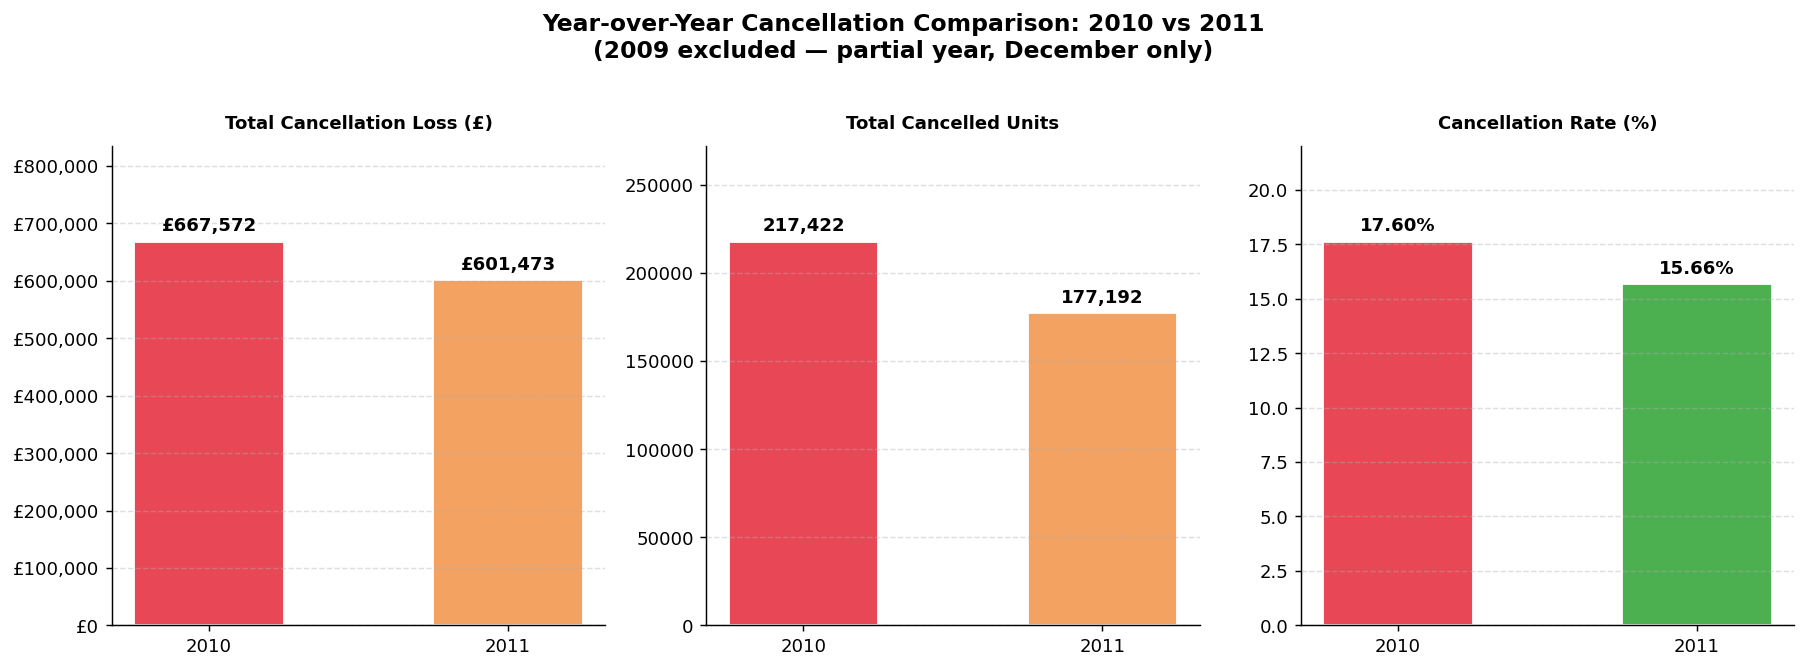


    Business Insight — Year-over-Year:
   Cancellation LOSS: 2010 £667,572 → 2011 £601,473  (-9.9%)
   Cancellation RATE: 2010 17.60% → 2011 15.66%  (-1.94 percentage points)

   POSITIVE TREND: The cancellation rate, cancellation loss, and number of cancel units decline year on year.
   This suggests incremental improvement in fulfilment or product quality or services.


In [21]:
# Year 2009 only has December — exclude from YoY to avoid bias
yoy = yearly[yearly.index.isin([2010, 2011])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('Cancel_Loss_GBP',  'Total Cancellation Loss (£)',  [C_RED, C_ORANGE]),
    ('Cancel_Units',     'Total Cancelled Units',        [C_RED, C_ORANGE]),
    ('Cancel_Rate_Pct',  'Cancellation Rate (%)',        [C_RED, C_GREEN])
]

for ax, (col, ylabel, colors) in zip(axes, metrics):
    bars = ax.bar(['2010', '2011'], yoy[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, yoy[col]):
        if col == 'Cancel_Loss_GBP':
            label = f'£{val:,.0f}'
        elif col == 'Cancel_Rate_Pct':
            label = f'{val:.2f}%'
        else:
            label = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontsize=10, pad=10)
    ax.set_ylim(0, yoy[col].max() * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if col == 'Cancel_Loss_GBP':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

fig.suptitle('Year-over-Year Cancellation Comparison: 2010 vs 2011\n'
             '(2009 excluded — partial year, December only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_yoy.png', bbox_inches='tight')
plt.show()

loss_change = ((yoy.loc[2011,'Cancel_Loss_GBP'] - yoy.loc[2010,'Cancel_Loss_GBP'])
               / yoy.loc[2010,'Cancel_Loss_GBP'] * 100)
rate_change  = yoy.loc[2011,'Cancel_Rate_Pct'] - yoy.loc[2010,'Cancel_Rate_Pct']
print()
print('    Business Insight — Year-over-Year:')
print(f'   Cancellation LOSS: 2010 £{yoy.loc[2010,"Cancel_Loss_GBP"]:,.0f} → '
      f'2011 £{yoy.loc[2011,"Cancel_Loss_GBP"]:,.0f}  ({loss_change:+.1f}%)')
print(f'   Cancellation RATE: 2010 {yoy.loc[2010,"Cancel_Rate_Pct"]:.2f}% → '
      f'2011 {yoy.loc[2011,"Cancel_Rate_Pct"]:.2f}%  ({rate_change:+.2f} percentage points)')
print()
print('   POSITIVE TREND: The cancellation rate, cancellation loss, and number of cancel units decline year on year.')
print('   This suggests incremental improvement in fulfilment or product quality or services.')

### 3.3 Monthly Cancellation Loss: Full Two-Year View

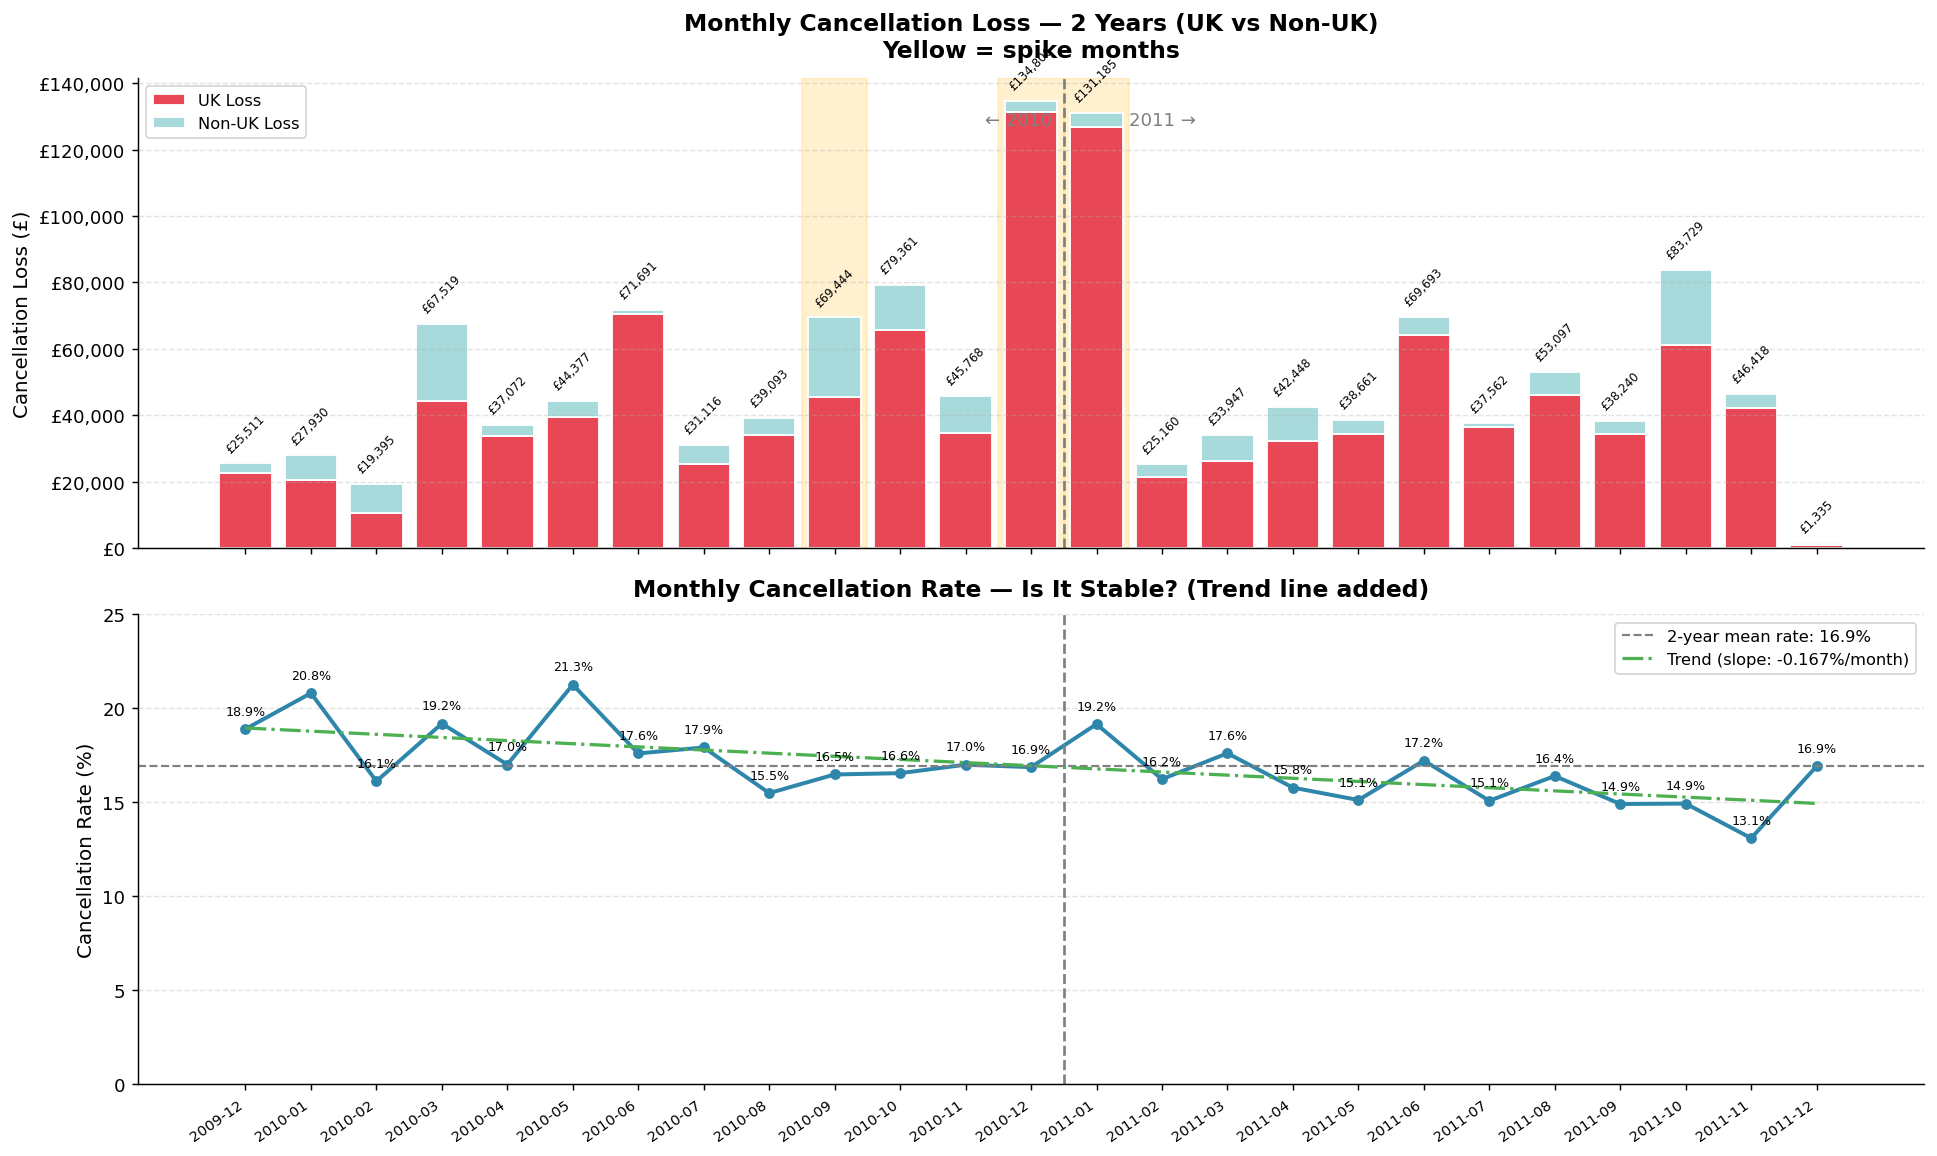


    Business Insight:
   2-year average cancel rate: 16.9%  — relatively flat throughout both years.
   Trend line slope: -0.167% per month — slight DOWNWARD trend (improving).
   Three notable spikes in LOSS: Sep 2010, Dec 2010, Jan 2011.
   KEY FINDING: Cancellation behaviour is mostly consistent. Losses vary with order volumes.


In [22]:
m_labels = [str(m) for m in monthly.index]
x = range(len(m_labels))

# Identify spike months
spike_labels = ['2010-12', '2011-01', '2010-09']
spike_idxs   = [i for i, m in enumerate(m_labels) if m in spike_labels]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# ── Top: stacked loss bars ────────────────────────────────────────────────────
ax1.bar(x, monthly['UK_Loss'].fillna(0),
        color=C_RED,  label='UK Loss',     edgecolor='white')
ax1.bar(x, monthly['NonUK_Loss'].fillna(0), color=C_TEAL, label='Non-UK Loss',
        bottom=monthly['UK_Loss'].fillna(0), edgecolor='white')

# Annotate total on each bar
for i, row in enumerate(monthly.itertuples()):
    total_bar = row.Cancel_Loss_GBP
    ax1.text(i, total_bar + 2500, f'£{total_bar:,.0f}',
             ha='center', va='bottom', fontsize=6.5, rotation=45)

# Shade spike months
for si in spike_idxs:
    ax1.axvspan(si - 0.5, si + 0.5, color=C_YELLOW, alpha=0.3, zorder=0)

# Year divider
year_boundary = m_labels.index('2011-01')
ax1.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
ax1.text(year_boundary - 1.2, ax1.get_ylim()[1] * 0.9 if ax1.get_ylim()[1] > 0 else 100000,
         '← 2010', ha='center', fontsize=10, color='grey')
ax1.text(year_boundary + 1, ax1.get_ylim()[1] * 0.9 if ax1.get_ylim()[1] > 0 else 100000,
         '2011 →', ha='center', fontsize=10, color='grey')

ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Monthly Cancellation Loss — 2 Years (UK vs Non-UK)\nYellow = spike months', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

# ── Bottom: rate line ─────────────────────────────────────────────────────────
ax2.plot(x, monthly['Cancel_Rate_Pct'],
         color=C_BLUE, marker='o', linewidth=2.2, markersize=5)
for i, v in enumerate(monthly['Cancel_Rate_Pct']):
    ax2.annotate(f'{v:.1f}%', (i, v), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7)

mean_rate = monthly['Cancel_Rate_Pct'].mean()
ax2.axhline(y=mean_rate, color='grey', linestyle='--', linewidth=1.2,
            label=f'2-year mean rate: {mean_rate:.1f}%')
ax2.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)

# Trend line
z = np.polyfit(list(x), monthly['Cancel_Rate_Pct'], 1)
p_trend = np.poly1d(z)
ax2.plot(x, p_trend(list(x)), color=C_GREEN, linestyle='-.', linewidth=1.8,
         label=f'Trend (slope: {z[0]:+.3f}%/month)')

ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Monthly Cancellation Rate — Is It Stable? (Trend line added)', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(m_labels, rotation=35, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('chart5_monthly_2yr.png', bbox_inches='tight')
plt.show()

print()
print('    Business Insight:')
print(f'   2-year average cancel rate: {mean_rate:.1f}%  — relatively flat throughout both years.')
print(f'   Trend line slope: {z[0]:+.3f}% per month — slight DOWNWARD trend (improving).')
print('   Three notable spikes in LOSS: Sep 2010, Dec 2010, Jan 2011.')
print('   KEY FINDING: Cancellation behaviour is mostly consistent. Losses vary with order volumes.')

### 3.4  Quarterly Seasonal Pattern Across Both Years

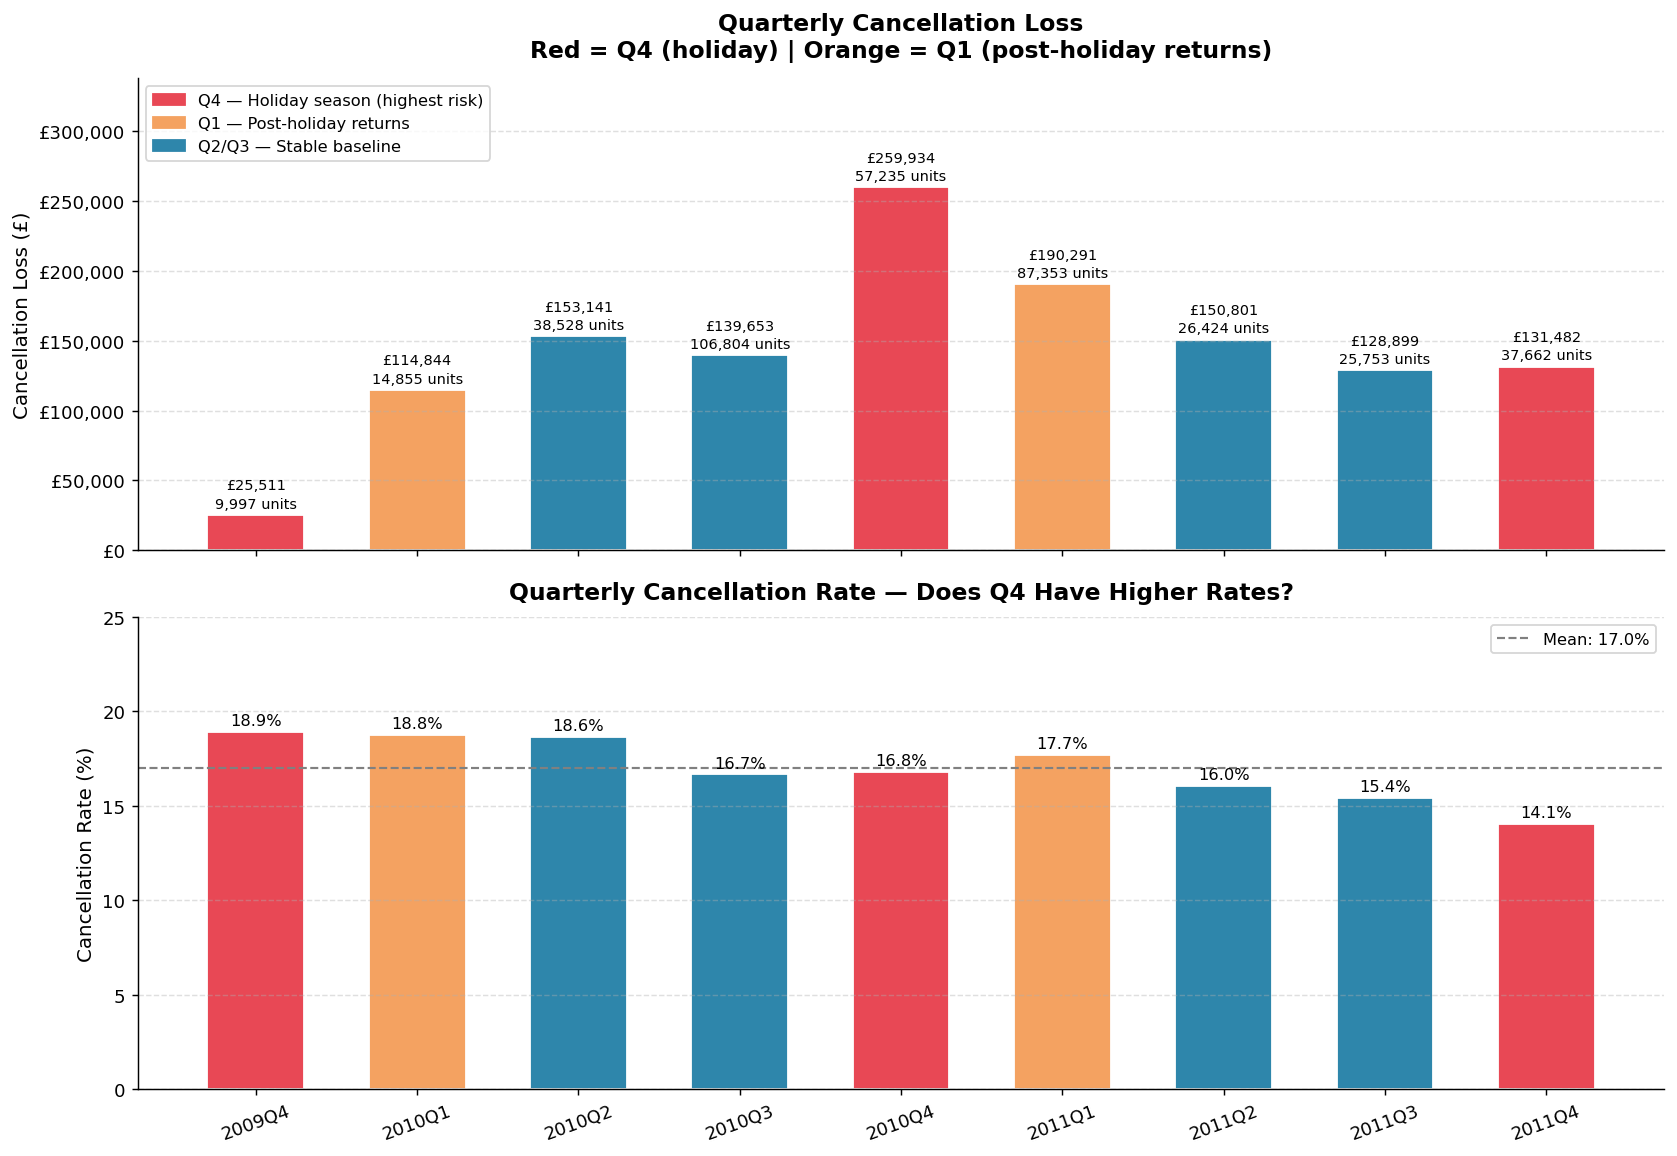


    Business Insight:
   Average Q4 loss: £138,976 vs Q2/Q3 baseline: £143,123
   Q4 2010 was the single worst quarter at £265k — driven by holiday order surge.
   Q4 2011 dropped to £133k, confirming the year-on-year improvement trend.
    The rate barely changes between Q4 and Q2/Q3 — confirming volume drives the spike.
   Business implication: Q4 risk is real but improving.
── NEXT EXPLORATION (connecting to product and customer sections) ──
The Q4 volume surge raises three follow-on questions:
1. Which specific products spike in Q4? → Okah to investigate
2. Are Q4 cancellations from the same customer IDs year after year? → Renato to investigate
3. Does Q4 loss concentration shift between UK and international markets? → Chart 9 above
These questions connect this section to the product and customer analyses.


In [23]:
q_labels = [str(q) for q in quarterly.index]

# Highlight Q4 quarters
q4_idxs = [i for i, q in enumerate(q_labels) if 'Q4' in q]
q1_idxs = [i for i, q in enumerate(q_labels) if 'Q1' in q]

bar_colors = []
for q in q_labels:
    if 'Q4' in q:   bar_colors.append(C_RED)
    elif 'Q1' in q: bar_colors.append(C_ORANGE)
    else:           bar_colors.append(C_BLUE)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Loss bars
bars = ax1.bar(q_labels, quarterly['Cancel_Loss_GBP'],
               color=bar_colors, edgecolor='white', width=0.6)

for bar, loss, units, rate in zip(bars, quarterly['Cancel_Loss_GBP'],
                                   quarterly['Cancel_Units'], quarterly['Cancel_Rate_Pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'£{loss:,.0f}\n{units:,.0f} units',
             ha='center', va='bottom', fontsize=8, linespacing=1.4)

ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Quarterly Cancellation Loss\nRed = Q4 (holiday) | Orange = Q1 (post-holiday returns)', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, quarterly['Cancel_Loss_GBP'].max() * 1.3)

legend_q = [
    mpatches.Patch(color=C_RED,    label='Q4 — Holiday season (highest risk)'),
    mpatches.Patch(color=C_ORANGE, label='Q1 — Post-holiday returns'),
    mpatches.Patch(color=C_BLUE,   label='Q2/Q3 — Stable baseline')
]
ax1.legend(handles=legend_q, fontsize=9, loc='upper left')

# Rate bars
ax2.bar(q_labels, quarterly['Cancel_Rate_Pct'],
        color=bar_colors, edgecolor='white', width=0.6)
for i, v in enumerate(quarterly['Cancel_Rate_Pct']):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax2.axhline(y=quarterly['Cancel_Rate_Pct'].mean(), color='grey',
            linestyle='--', linewidth=1.2,
            label=f'Mean: {quarterly["Cancel_Rate_Pct"].mean():.1f}%')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Quarterly Cancellation Rate — Does Q4 Have Higher Rates?', pad=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 25)
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart6_quarterly.png', bbox_inches='tight')
plt.show()

q4_avg_loss = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Loss_GBP'].mean()
q2q3_avg_loss = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Loss_GBP'].mean()
q4_avg_rate = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Rate_Pct'].mean()
q2q3_avg_rate = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Rate_Pct'].mean()

print()
print('    Business Insight:')
print(f'   Average Q4 loss: £{q4_avg_loss:,.0f} vs Q2/Q3 baseline: £{q2q3_avg_loss:,.0f}')
print(f'   Q4 2010 was the single worst quarter at £265k — driven by holiday order surge.')
print(f'   Q4 2011 dropped to £133k, confirming the year-on-year improvement trend.')
print('    The rate barely changes between Q4 and Q2/Q3 — confirming volume drives the spike.')
print(f'   Business implication: Q4 risk is real but improving.')

print('── NEXT EXPLORATION (connecting to product and customer sections) ──')
print('The Q4 volume surge raises three follow-on questions:')
print('1. Which specific products spike in Q4? → Okah to investigate')
print('2. Are Q4 cancellations from the same customer IDs year after year? → Renato to investigate')
print('3. Does Q4 loss concentration shift between UK and international markets? → Chart 9 above')
print('These questions connect this section to the product and customer analyses.')


### 3.5 Spike Month Products -
> **Connection to Product Section:** Identifying which SKUs drive spike-month losses.

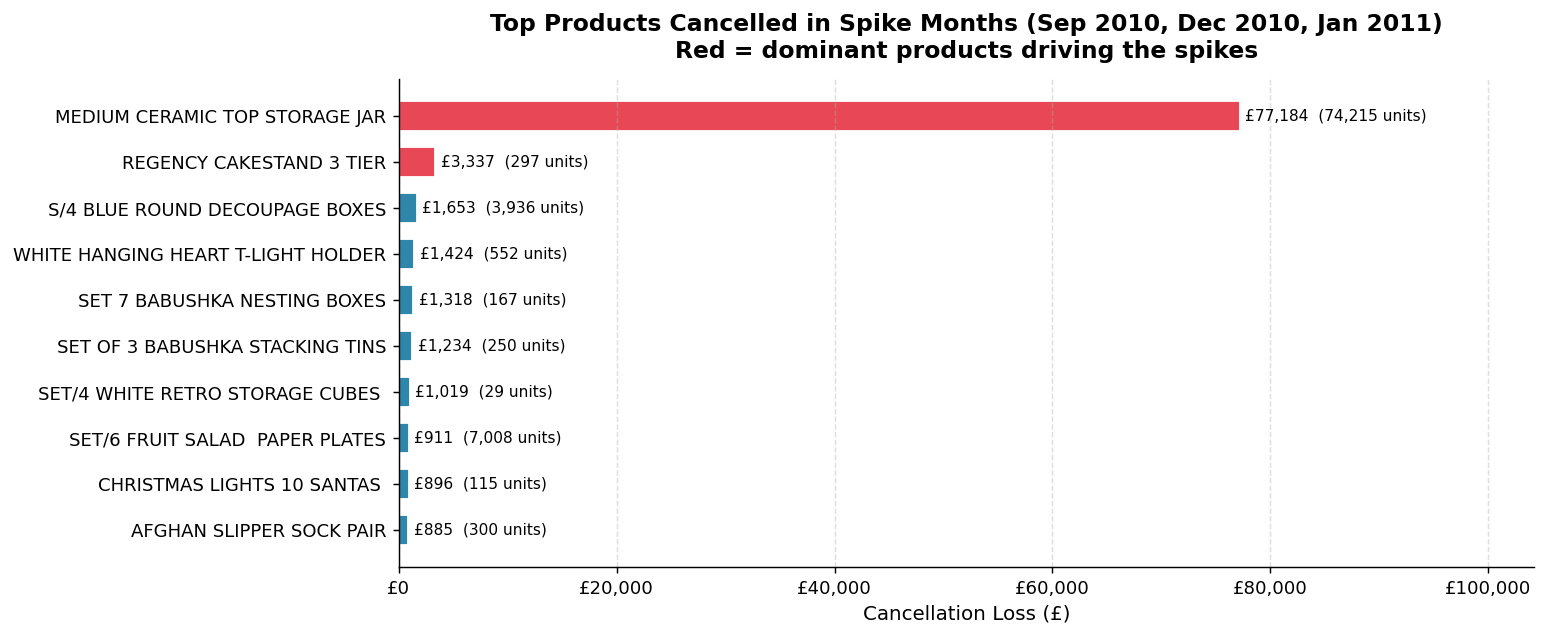


Business Insight — Spike Month Products:
   Total spike-month loss: £335,435
   Top SKU: MEDIUM CERAMIC TOP STORAGE JAR — 74,215 units | £77,184

   Losses are concentrated in 1–2 SKUs, not spread across many products.
   This pattern is consistent with a bulk order event — but confirmation
   requires checking Customer IDs (Renato) and SKU history (Okah).
   → Handoff to Okah: Is this SKU problematic outside spike months too?
   → Handoff to Renato: How many Customer IDs are behind these cancellations?


In [24]:
# Three major spike months across both years
spike_months = ['2010-09', '2010-12', '2011-01']
spike_df = df[
    (df['Cancelled']) &
    (df['Month'].astype(str).isin(spike_months))
].copy()

# Remove non-product entries
exclude_terms = ['AMAZON FEE', 'Manual', 'CRUK', 'Bank Charges',
                 'Adjust bad debt', 'Discount', 'nan', 'POST']
spike_products = (spike_df
                  .groupby('Description')
                  .agg(
                      Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                      Loss_GBP        = ('Loss',     'sum'),
                      Num_Invoices    = ('Invoice',  'nunique')
                  )
                  .sort_values('Loss_GBP', ascending=False))

spike_clean = spike_products[
    ~spike_products.index.str.contains('|'.join(exclude_terms), case=False, na=False)
].head(10).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_RED if i < 2 else C_BLUE for i in range(len(spike_clean))]
bars = ax.barh(spike_clean.index[::-1], spike_clean['Loss_GBP'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

for bar, units in zip(bars, spike_clean['Units_Cancelled'][::-1]):
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():,.0f}  ({units:,.0f} units)',
            va='center', fontsize=8.5)

ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top Products Cancelled in Spike Months (Sep 2010, Dec 2010, Jan 2011)\n'
             'Red = dominant products driving the spikes', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, spike_clean['Loss_GBP'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart8_spike_products.png', bbox_inches='tight')
plt.show()

total_spike_loss = spike_df['Loss'].sum()
top2_loss = spike_clean['Loss_GBP'].iloc[:2].sum()
print()
print('Business Insight — Spike Month Products:')
print(f'   Total spike-month loss: £{total_spike_loss:,.0f}')
print(f'   Top SKU: {spike_clean.index[0]} — {spike_clean["Units_Cancelled"].iloc[0]:,.0f} units | £{spike_clean["Loss_GBP"].iloc[0]:,.0f}')
print()
print('   Losses are concentrated in 1–2 SKUs, not spread across many products.')
print('   This pattern is consistent with a bulk order event — but confirmation')
print('   requires checking Customer IDs (Renato) and SKU history (Okah).')
print('   → Handoff to Okah: Is this SKU problematic outside spike months too?')
print('   → Handoff to Renato: How many Customer IDs are behind these cancellations?')

---
## GEOGRAPHIC & TEMPORAL ANALYSIS — SUMMARY INSIGHT.

# Consumer Section
**Section Owner:** Renato Silva

1. What share of customers’ accounts for the majority of return volume?
2. Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?
3. Is there a correlation between purchase frequency and return rate?


### Question 1: What share of customers’ accounts for the majority of return value?

In [25]:
# ── Filter: Top 6 countries covering 95% of cancellation loss ────────────────
TOP6_COUNTRIES = ['United Kingdom', 'EIRE', 'France', 'Norway', 'Spain', 'Germany']

df_top6_cancelled = df[
    (df['Is_Return'] == True) &
    (df['Country'].isin(TOP6_COUNTRIES))
].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'Total cancelled rows (top 6 countries) : {len(df_top6_cancelled):,}')
print(f'Countries included                      : {sorted(df_top6_cancelled["Country"].unique())}')
print(f'Date range                              : {df_top6_cancelled["InvoiceDate"].min().date()} → {df_top6_cancelled["InvoiceDate"].max().date()}')
print()

# ── Unique customers ──────────────────────────────────────────────────────────
cid_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'

unique_customers = df_top6_cancelled[cid_col].nunique()
unique_customers_no_nan = df_top6_cancelled[cid_col].dropna().nunique()

print(f'Unique customers (incl. NaN)  : {unique_customers:,}')
print(f'Unique customers (excl. NaN)  : {unique_customers_no_nan:,}')
print()

# ── Breakdown by country ──────────────────────────────────────────────────────
country_summary = (df_top6_cancelled
                   .groupby('Country')
                   .agg(
                       Cancelled_Rows     = ('Invoice',     'count'),
                       Unique_Customers   = (cid_col,       'nunique'),
                       Cancelled_Invoices = ('Invoice',     'nunique'),
                       Total_Loss_GBP     = ('Loss',        'sum')
                   )
                   .sort_values('Total_Loss_GBP', ascending=False)
                   .round(2))

print(country_summary.to_string())

Total cancelled rows (top 6 countries) : 18,010
Countries included                      : ['EIRE', 'France', 'Germany', 'Norway', 'Spain', 'United Kingdom']
Date range                              : 2009-12-01 → 2011-12-04

Unique customers (incl. NaN)  : 2,423
Unique customers (excl. NaN)  : 2,423

                Cancelled_Rows  Unique_Customers  Cancelled_Invoices  Total_Loss_GBP
Country                                                                             
United Kingdom           16149              2292                7045      1104222.13
EIRE                       508                 3                 178        48357.55
France                     369                42                 113        28228.60
Norway                      18                 4                   8        20866.59
Spain                       81                16                  29        16854.27
Germany                    885                66                 290        12516.40


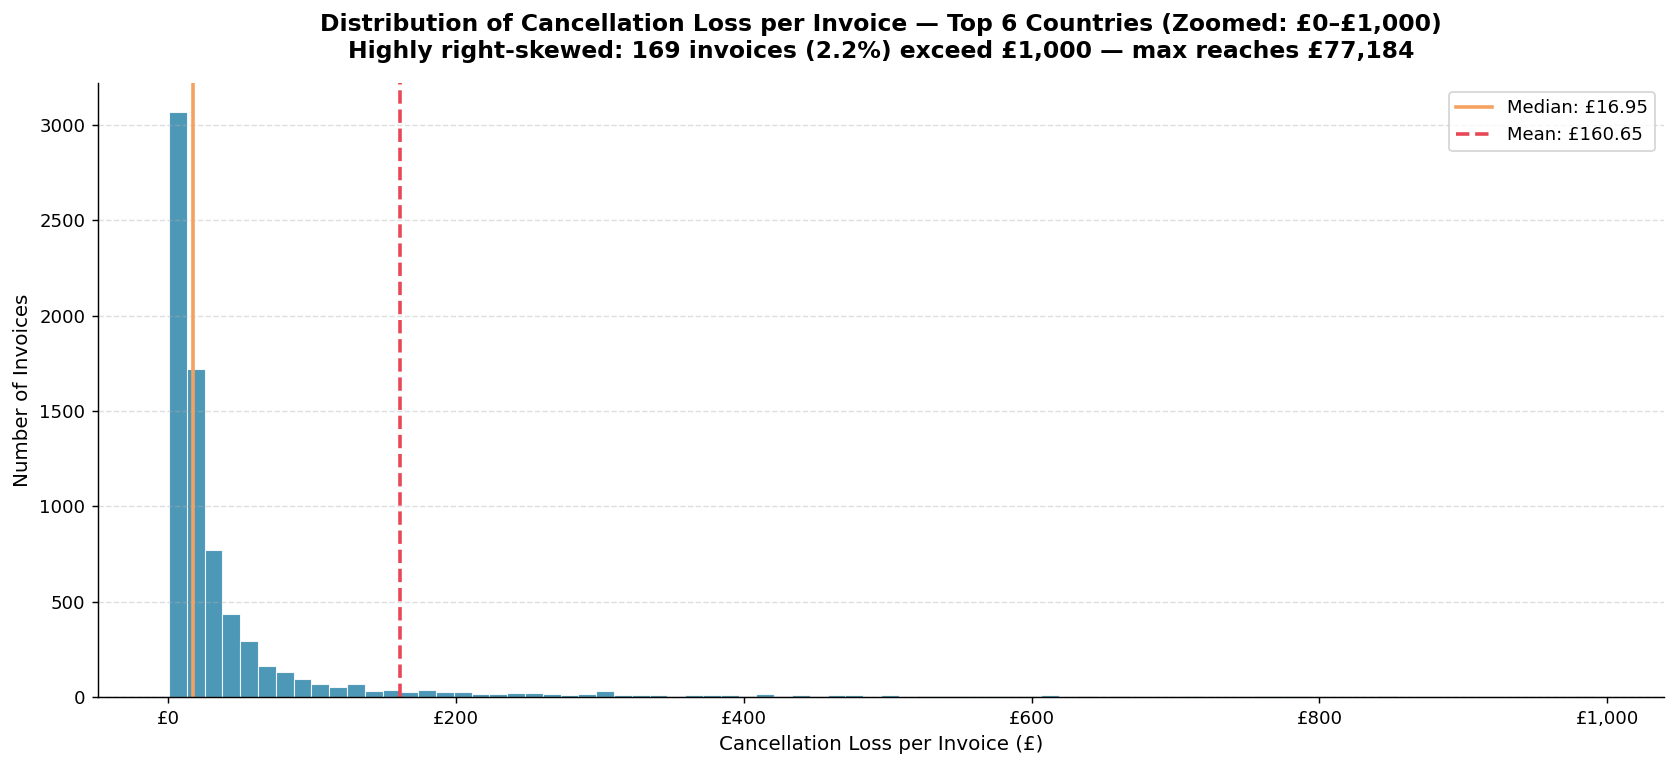

Invoices within £0–£1,000   : 7,494 (97.8%)
Invoices above £1,000       : 169 (2.2%)
Max invoice loss            : £77,183.60
Median                      : £16.95
Mean                        : £160.65


In [27]:
# ── Loss per cancelled invoice ────────────────────────────────────────────────
invoice_loss = (df_top6_cancelled
                .groupby('Invoice')['Loss']
                .sum()
                .reset_index()
                .rename(columns={'Loss': 'Invoice_Loss'}))
# ── Zoomed histogram: £0 – £1,000 ────────────────────────────────────────────
invoice_loss_filtered = invoice_loss[invoice_loss['Invoice_Loss'] <= 1000]

excluded = len(invoice_loss) - len(invoice_loss_filtered)
excluded_pct = excluded / len(invoice_loss) * 100
max_loss = invoice_loss['Invoice_Loss'].max()

fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(invoice_loss_filtered['Invoice_Loss'], bins=80, color=C_BLUE,
        edgecolor='white', linewidth=0.6, alpha=0.85)

ax.axvline(invoice_loss['Invoice_Loss'].median(), color=C_ORANGE,
           linewidth=2, label=f'Median: £{invoice_loss["Invoice_Loss"].median():,.2f}')
ax.axvline(invoice_loss['Invoice_Loss'].mean(), color=C_RED,
           linewidth=2, linestyle='--', label=f'Mean: £{invoice_loss["Invoice_Loss"].mean():,.2f}')

ax.set_xlabel('Cancellation Loss per Invoice (£)')
ax.set_ylabel('Number of Invoices')
ax.set_title(
    'Distribution of Cancellation Loss per Invoice — Top 6 Countries (Zoomed: £0–£1,000)\n'
    f'Highly right-skewed: {excluded:,} invoices ({excluded_pct:.1f}%) exceed £1,000 — max reaches £{max_loss:,.0f}',
    pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart_invoice_loss_distribution_zoomed.png', bbox_inches='tight')
plt.show()

print(f'Invoices within £0–£1,000   : {len(invoice_loss_filtered):,} ({100-excluded_pct:.1f}%)')
print(f'Invoices above £1,000       : {excluded:,} ({excluded_pct:.1f}%)')
print(f'Max invoice loss            : £{max_loss:,.2f}')
print(f'Median                      : £{invoice_loss["Invoice_Loss"].median():,.2f}')
print(f'Mean                        : £{invoice_loss["Invoice_Loss"].mean():,.2f}')

In [28]:
# ── Top 10 customers by total cancellation loss ───────────────────────────────
top10_customers = (df_top6_cancelled
                   .groupby(cid_col)['Loss']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .index.tolist())

# ── Build summary table ───────────────────────────────────────────────────────
summary = (df_top6_cancelled[df_top6_cancelled[cid_col].isin(top10_customers)]
           .groupby(cid_col)
           .agg(
               Country          = ('Country',  'first'),
               Total_Loss_GBP   = ('Loss',     'sum'),
               Cancelled_Invoices = ('Invoice', 'nunique'),
           )
           .sort_values('Total_Loss_GBP', ascending=False)
           .round(2))

# ── Cumulative loss share ─────────────────────────────────────────────────────
total_loss_all_customers = df_top6_cancelled['Loss'].sum()
summary['Loss_Share_Pct']       = (summary['Total_Loss_GBP'] / total_loss_all_customers * 100).round(2)
summary['Cumulative_Loss_Pct']  = summary['Loss_Share_Pct'].cumsum().round(2)

# ── Rename index for display ──────────────────────────────────────────────────
summary.index = [f'Customer {int(c)}' if not pd.isna(c) else 'Unknown'
                 for c in summary.index]

print('Top 10 Customers by Cancellation Loss')
print('=' * 60)
print(summary.to_string())

Top 10 Customers by Cancellation Loss
                       Country  Total_Loss_GBP  Cancelled_Invoices  Loss_Share_Pct  Cumulative_Loss_Pct
Customer 12346  United Kingdom        77620.14                   4            6.31                 6.31
Customer 15098  United Kingdom        39267.00                   2            3.19                 9.50
Customer 14063  United Kingdom        26477.40                   4            2.15                11.65
Customer 14911            EIRE        25169.42                 110            2.04                13.69
Customer 17399  United Kingdom        25111.09                   1            2.04                15.73
Customer 15749  United Kingdom        22998.40                   1            1.87                17.60
Customer 16029  United Kingdom        21925.44                   9            1.78                19.38
Customer 12918  United Kingdom        21907.00                   2            1.78                21.16
Customer 12931  United Kin

In [29]:
# ── Check if any customer appears in multiple countries ───────────────────────
customer_countries = (df_top6_cancelled
                      .groupby(cid_col)['Country']
                      .nunique()
                      .reset_index()
                      .rename(columns={'Country': 'Num_Countries'}))

multi_country = customer_countries[customer_countries['Num_Countries'] > 1]

print(f'Total unique customers          : {customer_countries[cid_col].nunique():,}')
print(f'Customers in multiple countries : {len(multi_country):,}')
print(f'Customers in a single country   : {len(customer_countries) - len(multi_country):,}')
print()

if len(multi_country) > 0:
    # Show which countries each multi-country customer appears in
    multi_detail = (df_top6_cancelled[df_top6_cancelled[cid_col].isin(multi_country[cid_col])]
                    .groupby(cid_col)['Country']
                    .unique()
                    .reset_index())
    print('Multi-country customers detail:')
    print(multi_detail.to_string())

Total unique customers          : 2,423
Customers in multiple countries : 0
Customers in a single country   : 2,423



In [30]:
# ── Loss per customer per country ─────────────────────────────────────────────
customer_country_loss = (df_top6_cancelled
                         .groupby(['Country', cid_col])['Loss']
                         .sum()
                         .reset_index()
                         .rename(columns={'Loss': 'Total_Loss_GBP'}))

# ── Statistical summary per country ──────────────────────────────────────────
country_stats = (customer_country_loss
                 .groupby('Country')['Total_Loss_GBP']
                 .agg(
                     Num_Customers = 'count',
                     Min           = 'min',
                     Q25           = lambda x: x.quantile(0.25),
                     Median        = 'median',
                     Mean          = 'mean',
                     Q75           = lambda x: x.quantile(0.75),
                     Max           = 'max',
                     Total_Loss    = 'sum'
                 )
                 .round(2)
                 .sort_values('Total_Loss', ascending=False))

print('Customer Loss Distribution by Country (£)')
print('=' * 80)
print(country_stats.to_string())

Customer Loss Distribution by Country (£)
                Num_Customers    Min      Q25    Median      Mean       Q75       Max  Total_Loss
Country                                                                                          
United Kingdom           2292   0.42    15.95     39.88    314.53    117.49  77620.14   720901.80
EIRE                        3  23.70  8702.69  17381.68  14191.60  21275.55  25169.42    42574.80
France                     42   3.90    15.49     86.40    672.11    237.16  12829.34    28228.60
Norway                      4  41.35   124.64    556.52   5216.65   5648.52  19712.21    20866.59
Spain                      16   5.77    19.25     52.62   1053.39    377.24  12387.07    16854.27
Germany                    66   4.95    31.67     61.53    189.64    196.38   1821.98    12516.40


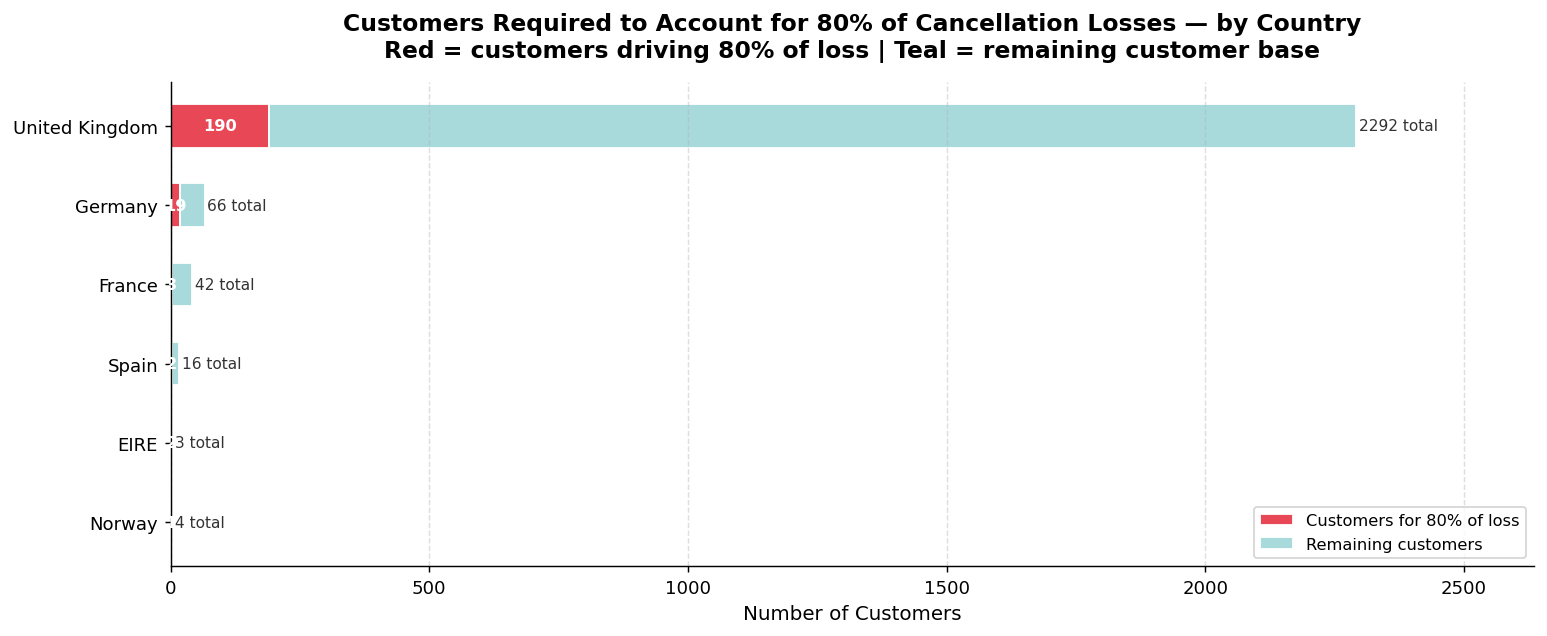

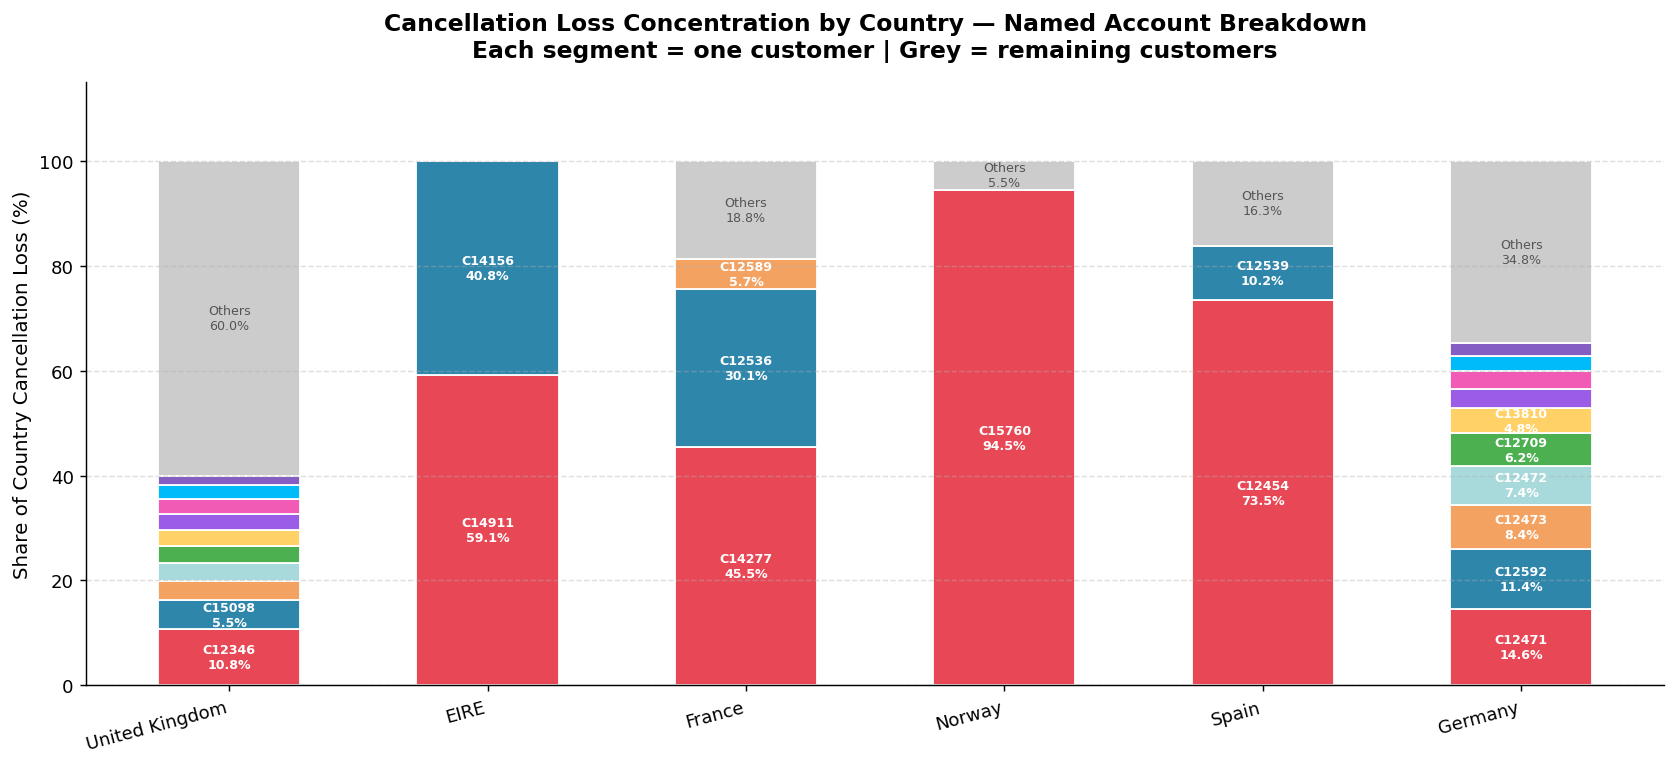

In [32]:
# ── Data preparation ──────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

# Customers needed to reach 80% per country
customers_for_80 = {}
total_customers  = {}

for country in TOP6_COUNTRIES:
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Cumulative_Loss_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).cumsum()
    at_80      = country_df[country_df['Cumulative_Loss_Pct'] <= 80]
    customers_for_80[country] = len(at_80) + 1
    total_customers[country]  = len(country_df)

summary_df = pd.DataFrame({
    'Country':        TOP6_COUNTRIES,
    'For_80_Pct':     [customers_for_80[c] for c in TOP6_COUNTRIES],
    'Total_Customers':[total_customers[c]  for c in TOP6_COUNTRIES]
}).sort_values('For_80_Pct', ascending=True)

summary_df['Others'] = summary_df['Total_Customers'] - summary_df['For_80_Pct']

# ── Chart 1 — Customers needed to reach 80% vs total ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.barh(summary_df['Country'], summary_df['For_80_Pct'],
                color=C_RED, edgecolor='white', label='Customers for 80% of loss', height=0.55)
bars2 = ax.barh(summary_df['Country'], summary_df['Others'],
                left=summary_df['For_80_Pct'],
                color=C_TEAL, edgecolor='white', label='Remaining customers', height=0.55)

for bar, val, total in zip(bars1, summary_df['For_80_Pct'], summary_df['Total_Customers']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{val}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

for bar, val, total in zip(bars2, summary_df['For_80_Pct'], summary_df['Total_Customers']):
    ax.text(bar.get_x() + bar.get_width() + 5,
            bar.get_y() + bar.get_height() / 2,
            f'{total} total', ha='left', va='center', fontsize=8.5, color='#333')

ax.set_xlabel('Number of Customers')
ax.set_title('Customers Required to Account for 80% of Cancellation Losses — by Country\n'
             'Red = customers driving 80% of loss | Teal = remaining customer base', pad=14)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, summary_df['Total_Customers'].max() * 1.15)

plt.tight_layout()
plt.savefig('chart_customers_80pct.png', bbox_inches='tight')
plt.show()

# ── Chart 2 — Stacked loss share per country ──────────────────────────────────
COLORS_PALETTE = [C_RED, C_BLUE, C_ORANGE, C_TEAL, C_GREEN,
                  C_YELLOW, '#9B5DE5', '#F15BB5', '#00BBF9', '#845EC2']

fig, ax = plt.subplots(figsize=(13, 6))

bar_positions = range(len(TOP6_COUNTRIES))
bottom        = [0] * len(TOP6_COUNTRIES)
legend_patches = []

# For each country define how many top accounts to name
TOP_N = {'United Kingdom': 10, 'EIRE': 2, 'France': 3,
         'Norway': 1, 'Spain': 2, 'Germany': 10}

for i, country in enumerate(TOP6_COUNTRIES):
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Loss_Share_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).round(2)

    top_n  = TOP_N[country]
    top_df = country_df.head(top_n)
    others = 100 - top_df['Loss_Share_Pct'].sum()

    for j, (_, row) in enumerate(top_df.iterrows()):
        color = COLORS_PALETTE[j % len(COLORS_PALETTE)]
        ax.bar(i, row['Loss_Share_Pct'], bottom=bottom[i],
               color=color, edgecolor='white', width=0.55)
        if row['Loss_Share_Pct'] > 4:
            ax.text(i, bottom[i] + row['Loss_Share_Pct'] / 2,
                    f'C{int(row[cid_col])}\n{row["Loss_Share_Pct"]:.1f}%',
                    ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        bottom[i] += row['Loss_Share_Pct']

    # Others segment
    if others > 0:
        ax.bar(i, others, bottom=bottom[i],
               color='#CCCCCC', edgecolor='white', width=0.55)
        if others > 4:
            ax.text(i, bottom[i] + others / 2,
                    f'Others\n{others:.1f}%',
                    ha='center', va='center', fontsize=7, color='#555')
        bottom[i] += others

ax.set_xticks(list(bar_positions))
ax.set_xticklabels(TOP6_COUNTRIES, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Share of Country Cancellation Loss (%)')
ax.set_ylim(0, 115)
ax.set_title('Cancellation Loss Concentration by Country — Named Account Breakdown\n'
             'Each segment = one customer | Grey = remaining customers', pad=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart_loss_concentration_stacked.png', bbox_inches='tight')
plt.show()

***Question 1 Answer:***

**EIRE — £42,574.80 | 3 customers**

Two accounts explain virtually all of EIRE's cancellation losses. Customer 14911 accounts for 59.12% (£25,169) and Customer 14156 for a further 40.83% (£17,381). There is no broader pattern to investigate. Resolving these two accounts eliminates the problem entirely.

---

**Norway — £20,866.59 | 4 customers**

Customer 15760 is responsible for £19,712 — 94.47% of Norway's total cancellation loss. The remaining three customers are minor losses in comparison. This is a single-account risk.

---

**France — £28,228.60 | 42 customers**

Three accounts drive 81.20% of French losses. Customer 14277 leads at 45.45% (£12,829), followed by Customer 12536 at 30.09% (£8,495), with Customer 12589 contributing a further 5.66% (£1,598). The remaining 39 customers represent 18% of total loses. Action on these three accounts addresses the vast majority of France's exposure.

---

***Spain — £16,854.27 | 16 customers***

Customer 12454 alone represents 73.50% of Spain's total losses at £12,387. Customer 12539 adds a further 10.18%. The remaining 14 customers collectively account for less than 17% of losses.

---

***Germany — £12,516.40 | 66 customers***

Germany has no dominant account. The largest customer represents only 14.56% of losses, and 19 customers are required to reach the 80% threshold across a base of 66. No single account-level intervention will move the needle here. Customer segmentation is recommended to determine whether these 19 accounts share common characteristics such as order size, or product category.

---

***United Kingdom — £720,901.80 | 2,292 customers***

The UK represents 85.2% of total cancellation losses across all six markets and requires a different approach. Customer 12346 (£77,620, 10.77%) and Customer 15098 (£39,267, 5.45%) stand out and merit individual review, as do the next several highest-value accounts. However, reaching 80% of UK losses requires 190 customers — a scale that makes purely account-level management impractical. Customer segmentation is strongly recommended to distinguish high-value B2B accounts from the broader retail base, and to identify whether the long tail follows patterns that can be addressed through operational or policy-level changes rather than individual account management.

### Question 2: Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?

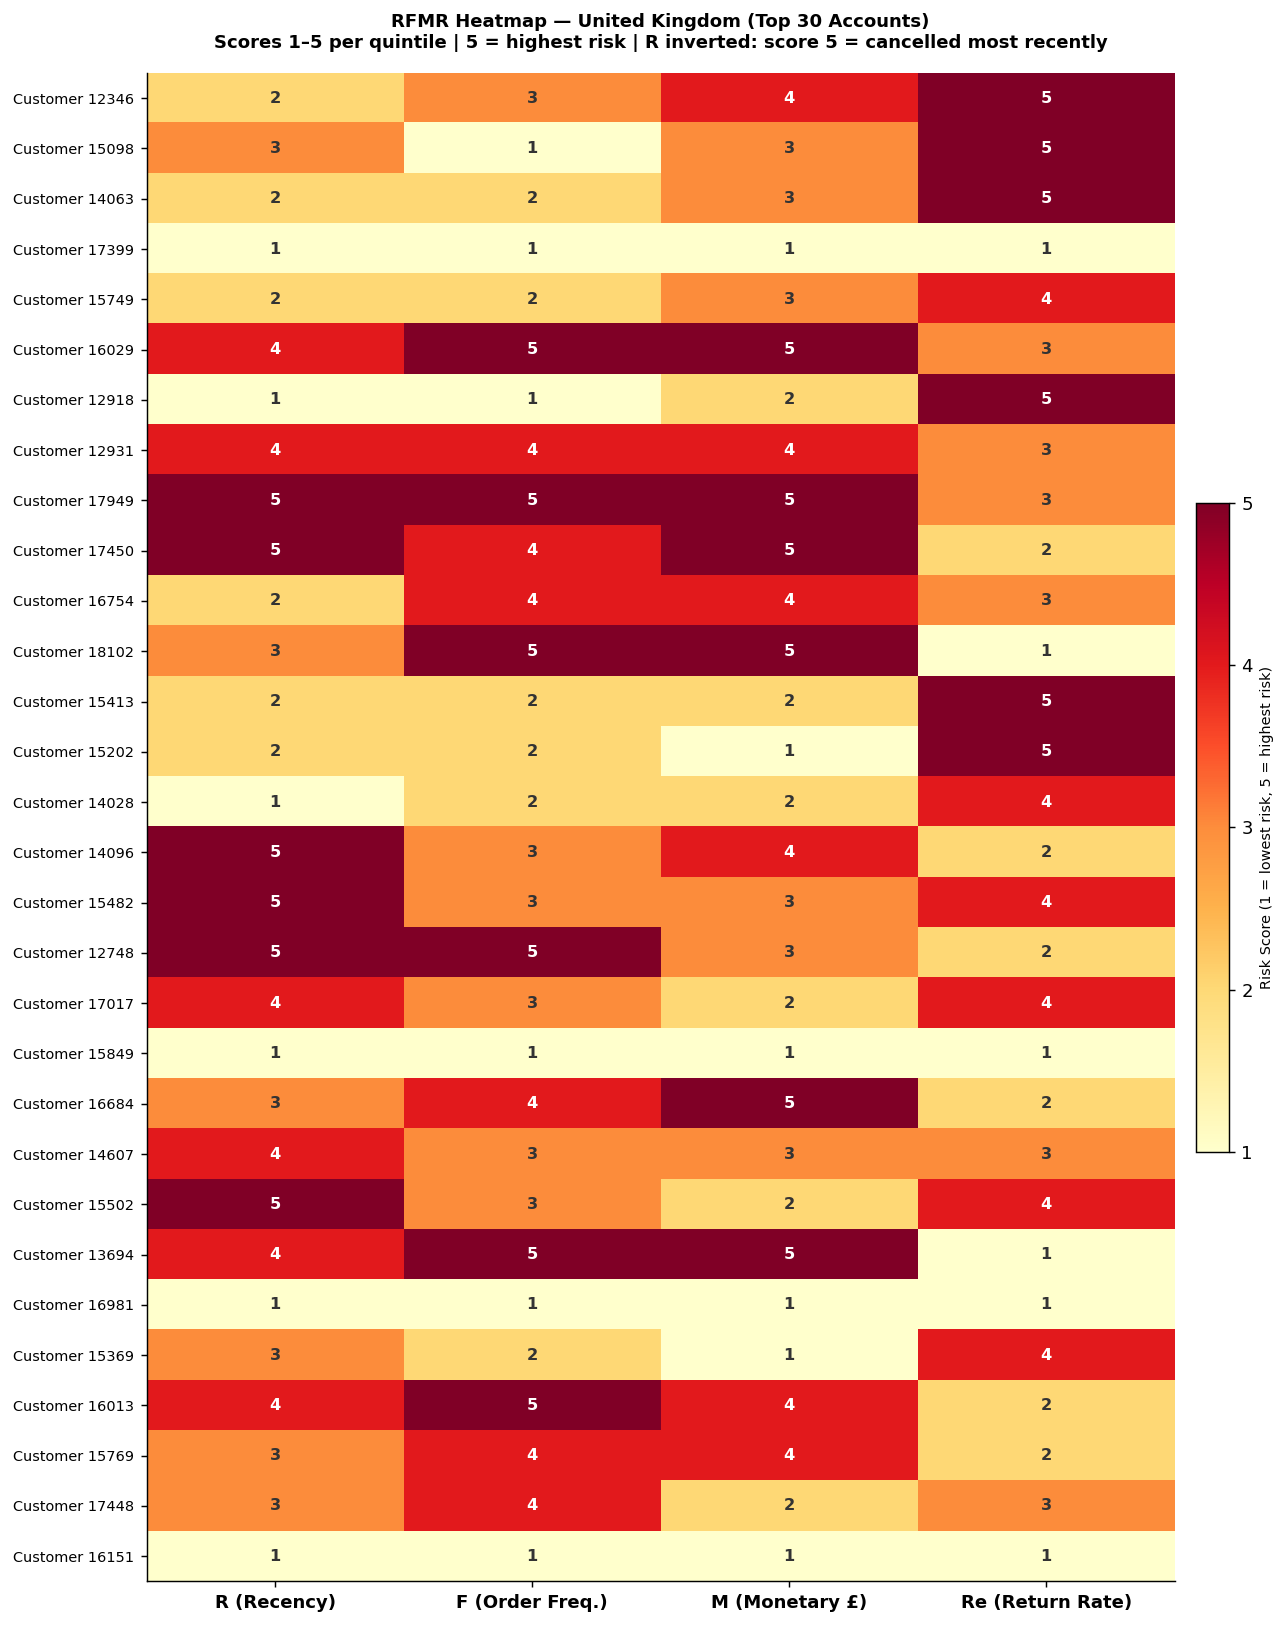

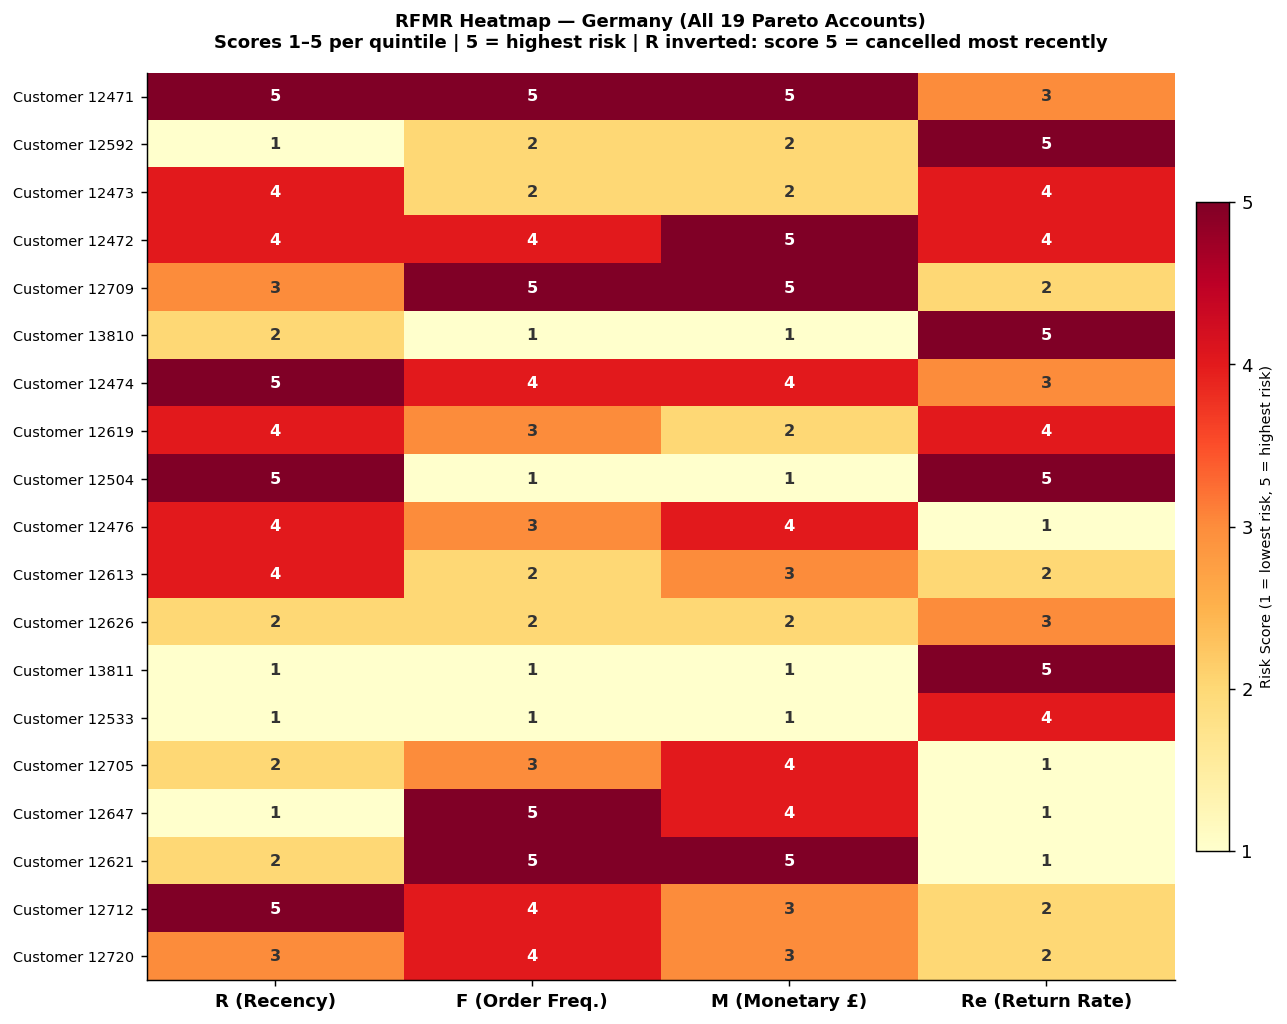

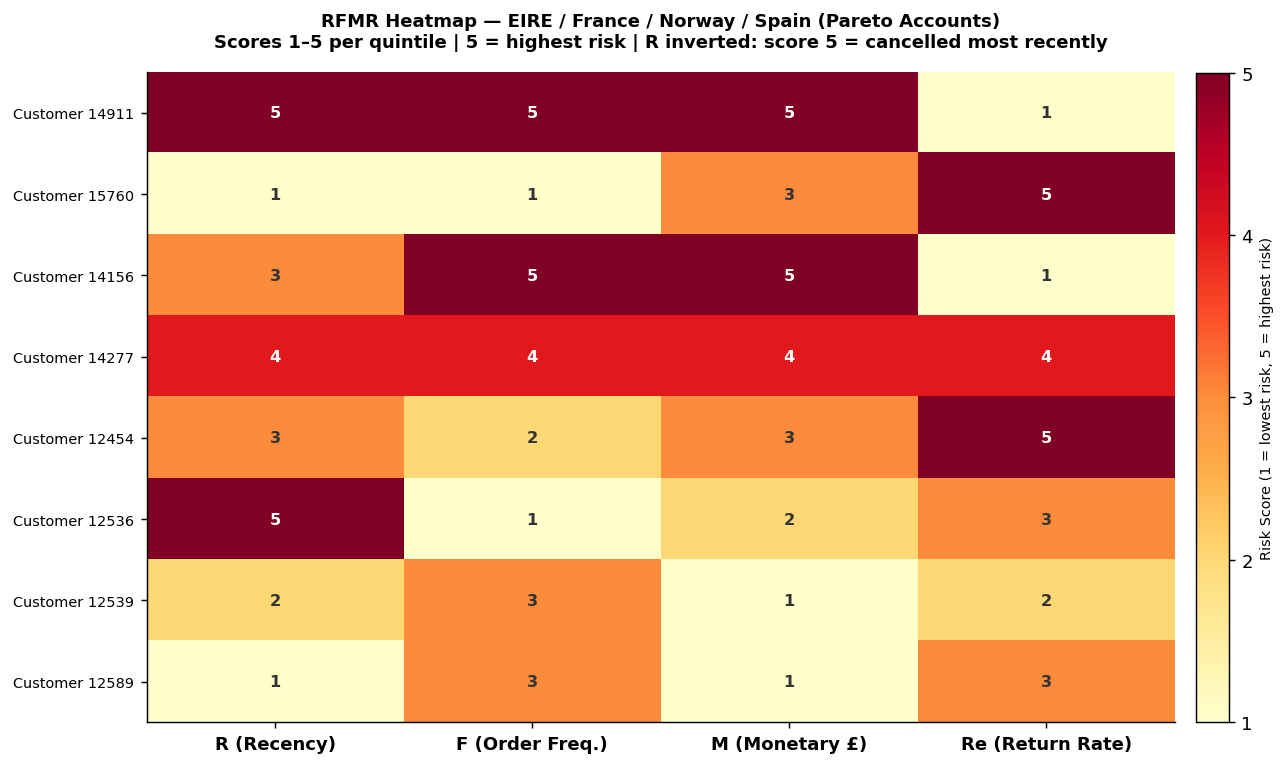

In [38]:
# ── Step 1: Rebuild RFMR with corrected F (total order frequency) ─────────────
DATASET_END = df['InvoiceDate'].max()

# Total order frequency from full df (all invoices, not just cancellations)
total_frequency = (df[df['Is_Return'] == False]
                   .groupby(cid_col)['Invoice']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Invoice': 'F_TotalOrders'}))

# Gross purchases
gross = (df[df['Is_Return'] == False]
         .assign(GrossValue = lambda x: x['Quantity'] * x['Price'])
         .groupby(cid_col)['GrossValue']
         .sum()
         .reset_index()
         .rename(columns={'GrossValue': 'M_GrossPurchases'}))

# Cancellation metrics
cancel = (df_top6_cancelled
          .groupby(cid_col)
          .agg(
              R_LastCancel  = ('InvoiceDate', 'max'),
              Re_CancelLoss = ('Loss',        'sum')
          )
          .reset_index())

cancel['R_Recency'] = (DATASET_END - cancel['R_LastCancel']).dt.days

# Merge all
rfmr = (cancel
        .merge(total_frequency, on=cid_col, how='left')
        .merge(gross,           on=cid_col, how='left'))

rfmr['F_TotalOrders']    = rfmr['F_TotalOrders'].fillna(0)
rfmr['M_GrossPurchases'] = rfmr['M_GrossPurchases'].fillna(0)
rfmr['Re_Rate']          = (rfmr['Re_CancelLoss'] /
                             rfmr['M_GrossPurchases'].replace(0, float('nan'))).round(4)
rfmr['Country']          = (df_top6_cancelled
                             .groupby(cid_col)['Country']
                             .first()
                             .reset_index()['Country'])

# ── Step 2: Split into three groups ──────────────────────────────────────────
display_cols = [cid_col, 'Country', 'R_Recency', 'F_TotalOrders',
                'M_GrossPurchases', 'Re_CancelLoss', 'Re_Rate']

rfmr_uk      = rfmr[rfmr[cid_col].isin(uk_customers)].copy()
rfmr_germany = rfmr[rfmr[cid_col].isin(germany_customers)].copy()
rfmr_other   = rfmr[rfmr[cid_col].isin(other_customers)].copy()

# ── Step 3: Scoring function (1–5 quintiles) ──────────────────────────────────
def score_rfmr(group_df, top_n=None):
    df_plot = group_df[display_cols].copy()
    df_plot = df_plot.sort_values('Re_CancelLoss', ascending=False)
    if top_n:
        df_plot = df_plot.head(top_n)

    # ── Fix: fill NaN in Re_Rate before scoring ───────────────────────────────
    df_plot['Re_Rate'] = df_plot['Re_Rate'].fillna(0)

    df_plot['Label'] = df_plot[cid_col].apply(
        lambda x: f'Customer {int(x)}' if not pd.isna(x) else 'Unknown')
    df_plot = df_plot.set_index('Label')

    scored = pd.DataFrame(index=df_plot.index)

    scored['R (Recency)']      = pd.qcut(df_plot['R_Recency'],
                                          q=5, labels=[5,4,3,2,1]).astype(int)
    scored['F (Order Freq.)']  = pd.qcut(df_plot['F_TotalOrders'].rank(method='first'),
                                          q=5, labels=[1,2,3,4,5]).astype(int)
    scored['M (Monetary £)']   = pd.qcut(df_plot['M_GrossPurchases'].rank(method='first'),
                                          q=5, labels=[1,2,3,4,5]).astype(int)
    scored['Re (Return Rate)'] = pd.qcut(df_plot['Re_Rate'].rank(method='first'),
                                          q=5, labels=[1,2,3,4,5]).astype(int)

    return scored

# ── Step 4: Heatmap function ──────────────────────────────────────────────────
def plot_rfmr_heatmap(scored_df, title):
    n_rows  = len(scored_df)
    fig_h   = max(6, n_rows * 0.42)
    fig, ax = plt.subplots(figsize=(10, fig_h))

    im = ax.imshow(scored_df.values.astype(float),
                   aspect='auto', cmap='YlOrRd', vmin=1, vmax=5)

    ax.set_xticks(range(len(scored_df.columns)))
    ax.set_xticklabels(scored_df.columns, fontsize=10, fontweight='bold')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(scored_df.index, fontsize=8)

    for i in range(n_rows):
        for j in range(len(scored_df.columns)):
            val   = scored_df.iloc[i, j]
            color = 'white' if val >= 4 else '#333333'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_label('Risk Score (1 = lowest risk, 5 = highest risk)', fontsize=8)

    ax.set_title(
        f'{title}\n'
        f'Scores 1–5 per quintile | 5 = highest risk | '
        f'R inverted: score 5 = cancelled most recently',
        pad=14, fontsize=10)

    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('/', '').replace('—','').strip() + '.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

# ── Step 5: Plot all three ────────────────────────────────────────────────────
plot_rfmr_heatmap(score_rfmr(rfmr_uk, top_n=30),
                  'RFMR Heatmap — United Kingdom (Top 30 Accounts)')

plot_rfmr_heatmap(score_rfmr(rfmr_germany),
                  'RFMR Heatmap — Germany (All 19 Pareto Accounts)')

plot_rfmr_heatmap(score_rfmr(rfmr_other),
                  'RFMR Heatmap — EIRE / France / Norway / Spain (Pareto Accounts)')

# 4. Product Analysis — Online Retail Returns
**Section Owner:** Okah Ahone Ebwekoh  
**Dataset:** Online Retail II — Full Two-Year Span (Dec 2009 – Dec 2011)

---
## Analytical Story

This section answers the question: **which products are causing losses, and why?**

**Three key questions this section answers:**
1. Which products have the highest return rates as a share of units sold?
2. Do high-return products share characteristics such as price range or category?
3. Does a Pareto pattern hold — do a small number of products account for most returns on quantity and sales?




In [ ]:
# ── Filter: Top 6 countries covering 95% of cancellation loss ────────────────
TOP6_COUNTRIES = ['United Kingdom', 'EIRE', 'France', 'Norway', 'Spain', 'Germany']

df_top6_cancelled = df[
    (df['Is_Return'] == True) &
    (df['Country'].isin(TOP6_COUNTRIES))
].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'Total cancelled rows (top 6 countries) : {len(df_top6_cancelled):,}')
print(f'Countries included                      : {sorted(df_top6_cancelled["Country"].unique())}')
print(f'Date range                              : {df_top6_cancelled["InvoiceDate"].min().date()} → {df_top6_cancelled["InvoiceDate"].max().date()}')
print()

# ── Unique customers ──────────────────────────────────────────────────────────
cid_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'

unique_customers = df_top6_cancelled[cid_col].nunique()
unique_customers_no_nan = df_top6_cancelled[cid_col].dropna().nunique()

print(f'Unique customers (incl. NaN)  : {unique_customers:,}')
print(f'Unique customers (excl. NaN)  : {unique_customers_no_nan:,}')
print()

# ── Breakdown by country ──────────────────────────────────────────────────────
country_summary = (df_top6_cancelled
                   .groupby('Country')
                   .agg(
                       Cancelled_Rows     = ('Invoice',     'count'),
                       Unique_Customers   = (cid_col,       'nunique'),
                       Cancelled_Invoices = ('Invoice',     'nunique'),
                       Total_Loss_GBP     = ('Loss',        'sum')
                   )
                   .sort_values('Total_Loss_GBP', ascending=False)
                   .round(2))

print(country_summary.to_string())

---
## Product-Level Summary Table
> Build a master product table with cancellation rates, loss, and units — the foundation for all charts below.

In [ ]:
# ── Total units sold per SKU (non-cancelled, positive qty) ────────────────────
sold = (df_products[~df_products['Cancelled'] & (df_products['Quantity'] > 0)]
        .groupby('StockCode')
        .agg(
            Description      = ('Description', lambda x: x.mode()[0]),
            Units_Sold       = ('Quantity', 'sum'),
            Avg_Price        = ('Price', 'mean'),
            Total_Invoices   = ('Invoice', 'nunique')
        ))

# ── Cancelled units and loss per SKU ──────────────────────────────────────────
cancelled = (df_cancelled
             .groupby('StockCode')
             .agg(
                 Units_Cancelled  = ('Quantity', lambda x: x.abs().sum()),
                 Loss_GBP         = ('Loss', 'sum'),
                 Cancel_Invoices  = ('Invoice', 'nunique')
             ))

# ── Merge into master product table ──────────────────────────────────────────
products = sold.join(cancelled, how='left').fillna(0)
products['Units_Cancelled'] = products['Units_Cancelled'].astype(int)
products['Loss_GBP']        = products['Loss_GBP'].round(2)

# Cancel rate = cancelled units / (sold + cancelled units)
total_units = products['Units_Sold'] + products['Units_Cancelled']
products['Cancel_Rate_Pct'] = (products['Units_Cancelled'] / total_units * 100).round(2)

# Loss share
total_cancel_loss = products['Loss_GBP'].sum()
products['Loss_Share_Pct'] = (products['Loss_GBP'] / total_cancel_loss * 100).round(3)

# Filter: only include SKUs with at least 10 cancelled units (removes noise)
products_sig = products[products['Units_Cancelled'] >= 10].copy()

print(f'Significant SKUs (>=10 cancelled units): {len(products_sig):,}')
print(f'Top 10 by cancellation loss:')
print()
print(products_sig.sort_values('Loss_GBP', ascending=False)
      [['Description','Units_Cancelled','Units_Sold','Cancel_Rate_Pct','Loss_GBP','Avg_Price']]
      .head(10).to_string())

---
## 3. Chart 1 — Top 15 Products by Cancellation Loss (Pareto)
> **Analytical goal:** Test whether a Pareto pattern holds at the product level.
> If a small number of SKUs drive the majority of losses, the business can focus intervention.

In [ ]:
top15_loss = products_sig.sort_values('Loss_GBP', ascending=False).head(15).copy()
top15_loss['Cumulative_Pct'] = top15_loss['Loss_Share_Pct'].cumsum().round(1)

# Truncate long descriptions for axis labels
top15_loss['Label'] = top15_loss['Description'].str[:35]

fig, ax1 = plt.subplots(figsize=(14, 6))

bar_colors = [C_RED if i < 3 else C_BLUE for i in range(len(top15_loss))]
bars = ax1.bar(top15_loss['Label'], top15_loss['Loss_GBP'],
               color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, top15_loss['Loss_GBP']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + top15_loss['Loss_GBP'].max() * 0.01,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=7.5, color='#333', rotation=0)

ax1.set_ylabel('Cancellation Loss — 2 Years (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=40)
ax1.set_xticklabels(top15_loss['Label'], rotation=45, ha='right', fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.set_title('Top 15 Products by Cancellation Loss — Pareto Test\n'
              'Red = top 3 SKUs | Blue = remaining | Line = cumulative share (%)', pad=14)

ax2 = ax1.twinx()
ax2.plot(top15_loss['Label'], top15_loss['Cumulative_Pct'],
         color=C_ORANGE, marker='o', linewidth=2.2, markersize=7, zorder=5)
for x, y in zip(top15_loss['Label'], top15_loss['Cumulative_Pct']):
    ax2.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                 xytext=(0, 9), ha='center', fontsize=8, color=C_ORANGE)
ax2.axhline(y=80, color='grey', linestyle=':', linewidth=1.5, label='80% threshold')
ax2.set_ylabel('Cumulative Loss Share (%)', color=C_ORANGE)
ax2.set_ylim(0, 115)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)
ax2.legend(loc='center right', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_product_pareto.png', bbox_inches='tight')
plt.show()

top3_loss  = top15_loss['Loss_GBP'].iloc[:3].sum()
top5_loss  = top15_loss['Loss_GBP'].iloc[:5].sum()
top15_share = top15_loss['Loss_Share_Pct'].sum()
print()
print('📌 Business Insight — Chart 1:')
print(f'   Top 3 SKUs account for £{top3_loss:,.0f} of cancellation losses.')
print(f'   Top 5 SKUs: £{top5_loss:,.0f} — cumulative share: {top15_loss["Cumulative_Pct"].iloc[4]:.1f}%')
print(f'   Top 15 SKUs: {top15_share:.1f}% of ALL product cancellation losses.')
print()
print('   ✅ Pareto pattern CONFIRMED at the product level.')
print('   The business does not have a broadly distributed return problem — it has a')
print('   concentrated SKU problem. Fixing the top 15 products addresses the majority of loss.')

---
## 4. Chart 2 — High Cancel-Rate Products (Rate vs. Volume Scatter)
> **Analytical goal:** Separate products that are high-risk by RATE from those high-risk by VOLUME.
> These are two different problems requiring different fixes — same distinction Sandra made at country level.

In [ ]:
# Focus on products with meaningful volume: at least 50 total units moved
scatter_df = products_sig[
    (products_sig['Units_Sold'] + products_sig['Units_Cancelled']) >= 50
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

# Colour by risk quadrant
median_rate = scatter_df['Cancel_Rate_Pct'].median()
median_loss = scatter_df['Loss_GBP'].median()

def quadrant_color(row):
    if row['Cancel_Rate_Pct'] > median_rate and row['Loss_GBP'] > median_loss:
        return C_RED       # High rate + high loss = critical
    elif row['Cancel_Rate_Pct'] > median_rate:
        return C_ORANGE    # High rate, lower loss = structural risk
    elif row['Loss_GBP'] > median_loss:
        return C_BLUE      # Low rate, high loss = volume risk
    return C_TEAL          # Low rate, low loss = manageable

scatter_df['Color'] = scatter_df.apply(quadrant_color, axis=1)

ax.scatter(scatter_df['Cancel_Rate_Pct'], scatter_df['Loss_GBP'],
           c=scatter_df['Color'], alpha=0.65, s=60, edgecolors='white', linewidth=0.4)

# Label top 10 by loss
top10_label = scatter_df.nlargest(10, 'Loss_GBP')
for _, row in top10_label.iterrows():
    ax.annotate(str(row['Description'])[:28],
                (row['Cancel_Rate_Pct'], row['Loss_GBP']),
                fontsize=7, xytext=(5, 4), textcoords='offset points',
                color='#333')

# Quadrant dividers
ax.axvline(x=median_rate, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=median_loss, color='grey', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
ax.text(median_rate * 0.1,  scatter_df['Loss_GBP'].max() * 0.92, 'Volume Risk\n(low rate, high loss)',
        fontsize=8, color=C_BLUE, style='italic')
ax.text(scatter_df['Cancel_Rate_Pct'].max() * 0.6, scatter_df['Loss_GBP'].max() * 0.92,
        'Critical\n(high rate + high loss)',
        fontsize=8, color=C_RED, style='italic')
ax.text(median_rate * 0.1, median_loss * 0.1, 'Manageable',
        fontsize=8, color=C_TEAL, style='italic')
ax.text(scatter_df['Cancel_Rate_Pct'].max() * 0.6, median_loss * 0.1,
        'Structural Risk\n(high rate, lower loss)',
        fontsize=8, color=C_ORANGE, style='italic')

ax.set_xlabel('Cancellation Rate (% of units moved)')
ax.set_ylabel('Total Cancellation Loss (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_title('Product Risk Map: Cancellation Rate vs. Cancellation Loss\n'
             'Red = critical | Blue = volume risk | Orange = structural risk | Teal = manageable',
             pad=12)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,    label='Critical (high rate + high loss)'),
    mpatches.Patch(facecolor=C_BLUE,   label='Volume Risk (low rate, high loss)'),
    mpatches.Patch(facecolor=C_ORANGE, label='Structural Risk (high rate, lower loss)'),
    mpatches.Patch(facecolor=C_TEAL,   label='Manageable'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.savefig('chart2_product_risk_map.png', bbox_inches='tight')
plt.show()

critical    = scatter_df[scatter_df['Color'] == C_RED]
volume_risk = scatter_df[scatter_df['Color'] == C_BLUE]
struct_risk = scatter_df[scatter_df['Color'] == C_ORANGE]
print()
print('📌 Business Insight — Chart 2:')
print(f'   Critical SKUs (high rate + high loss): {len(critical)} products')
print(f'   Volume Risk SKUs:    {len(volume_risk)} products')
print(f'   Structural Risk SKUs: {len(struct_risk)} products')
print()
print('   Critical products are the priority — they fail often AND cost the most.')
print('   Volume risk products may be fine products caught in bulk-order cancellations.')
print('   Structural risk products need description or quality review — they fail disproportionately.')

---
## 5. Chart 3 — Price Band Analysis: Do High-Return Products Cluster in Specific Price Ranges?
> **Analytical goal:** Identify whether cancellation risk is concentrated in a specific price tier.
> This supports product management decisions around pricing, description quality, and expectation-setting.

In [ ]:
# ── Assign price bands ────────────────────────────────────────────────────────
bins   = [0, 1, 2.5, 5, 10, 25, np.inf]
labels = ['<£1', '£1–2.50', '£2.50–5', '£5–10', '£10–25', '£25+']

products_sig['Price_Band'] = pd.cut(products_sig['Avg_Price'], bins=bins, labels=labels)

band_summary = products_sig.groupby('Price_Band', observed=True).agg(
    Num_SKUs         = ('Loss_GBP',         'count'),
    Total_Loss       = ('Loss_GBP',         'sum'),
    Avg_Cancel_Rate  = ('Cancel_Rate_Pct',  'mean'),
    Total_Units_Canc = ('Units_Cancelled',  'sum')
).round(2)

band_summary['Loss_Share_Pct'] = (band_summary['Total_Loss'] / band_summary['Total_Loss'].sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Loss by price band
bar_colors_band = [C_RED if v == band_summary['Total_Loss'].max() else C_BLUE
                   for v in band_summary['Total_Loss']]
bars1 = ax1.bar(band_summary.index, band_summary['Total_Loss'],
                color=bar_colors_band, edgecolor='white')
for bar, share in zip(bars1, band_summary['Loss_Share_Pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + band_summary['Total_Loss'].max() * 0.01,
             f'{share:.1f}%', ha='center', va='bottom', fontsize=9)
ax1.set_title('Cancellation Loss by Product Price Band\n% labels = share of total loss', pad=10)
ax1.set_ylabel('Total Cancellation Loss (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.set_xlabel('Price Band')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Right: Avg cancel rate by price band
bar_colors_rate = [C_ORANGE if v == band_summary['Avg_Cancel_Rate'].max() else C_TEAL
                   for v in band_summary['Avg_Cancel_Rate']]
bars2 = ax2.bar(band_summary.index, band_summary['Avg_Cancel_Rate'],
                color=bar_colors_rate, edgecolor='white')
for bar, val in zip(bars2, band_summary['Avg_Cancel_Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax2.set_title('Average Cancellation Rate by Product Price Band\nOrange = highest rate tier', pad=10)
ax2.set_ylabel('Average Cancellation Rate (%)')
ax2.set_xlabel('Price Band')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Do High-Return Products Cluster in a Specific Price Range?', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_price_band.png', bbox_inches='tight')
plt.show()

highest_loss_band = band_summary['Total_Loss'].idxmax()
highest_rate_band = band_summary['Avg_Cancel_Rate'].idxmax()
print()
print('📌 Business Insight — Chart 3:')
print(f'   Price band with highest total loss:     {highest_loss_band}')
print(f'   Price band with highest cancel rate:    {highest_rate_band}')
print()
print(band_summary[['Num_SKUs','Total_Loss','Loss_Share_Pct','Avg_Cancel_Rate']].to_string())
print()
print('   If the highest-loss and highest-rate bands are different: two distinct problems.')
print('   High-loss band = large-quantity products being bulk-cancelled.')
print('   High-rate band = products frequently returned individually (description/quality issue).')

---
## 6. Chart 4 — Products Cancelled in Structurally Broken Markets
> **Directly answering Sandra's handoff question:**
> What products are being cancelled in Germany, Japan, and Malta?
> Do they share characteristics with what gets cancelled in the UK?

In [ ]:
TARGET_MARKETS = ['United Kingdom', 'EIRE', 'France', 'Norway', 'Spain', 'Germany']
# All 6 countries in the 95% loss threshold

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

market_colors = [C_RED, C_BLUE, C_ORANGE, C_TEAL, C_GREEN, C_YELLOW]

market_top_products = {}

for idx, (market, color) in enumerate(zip(TARGET_MARKETS, market_colors)):
    ax = axes_flat[idx]
    market_cancelled = df_cancelled[df_cancelled['Country'] == market]

    if len(market_cancelled) == 0:
        ax.text(0.5, 0.5, f'No data for {market}', ha='center', va='center', transform=ax.transAxes)
        continue

    top_products = (market_cancelled
                    .groupby('Description')
                    .agg(
                        Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                        Loss_GBP        = ('Loss', 'sum'),
                        Num_Invoices    = ('Invoice', 'nunique')
                    )
                    .sort_values('Loss_GBP', ascending=False)
                    .head(10)
                    .round(2))
    market_top_products[market] = top_products

    labels = [str(d)[:32] for d in top_products.index]
    bars = ax.barh(labels[::-1], top_products['Loss_GBP'].values[::-1],
                   color=color, edgecolor='white', height=0.65, alpha=0.85)

    for bar, units in zip(bars, top_products['Units_Cancelled'].values[::-1]):
        ax.text(bar.get_width() + top_products['Loss_GBP'].max() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'£{bar.get_width():,.0f}  ({units:,.0f} units)',
                va='center', fontsize=7.5)

    total_market_loss = market_cancelled['Loss'].sum()
    top_share = top_products['Loss_GBP'].sum() / total_market_loss * 100

    ax.set_title(f'{market}\nTop 10 Cancelled Products — Total market loss: £{total_market_loss:,.0f}\n'
                 f'Top 10 account for {top_share:.1f}% of {market} losses',
                 color=color, pad=8, fontsize=10)
    ax.set_xlabel('Cancellation Loss (£)', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    ax.set_xlim(0, top_products['Loss_GBP'].max() * 1.45)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top Cancelled Products by Market — UK vs Structurally Broken Markets\n'
             'Do Germany, Japan, Malta cancel the same SKUs as the UK?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart4_products_by_market.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 4:')
print('   Compare the product lists across markets.')
print()
print('   If SAME products appear across UK + international markets:')
print('   → The product itself is the problem (quality, description, packaging).')
print('   → Fix the product globally.')
print()
print('   If DIFFERENT products dominate in international markets:')
print('   → Product-market mismatch — products that work in the UK do not suit these markets.')
print('   → Review the product catalogue offered per country.')
print()

# Find product overlap between UK and international markets
uk_top = set(market_top_products.get('United Kingdom', pd.DataFrame()).index[:10])
for market in ['Germany', 'Japan', 'Malta']:
    intl_top = set(market_top_products.get(market, pd.DataFrame()).index[:10])
    overlap  = uk_top & intl_top
    print(f'   Products in BOTH UK top-10 and {market} top-10: {len(overlap)}')
    if overlap:
        for p in overlap: print(f'     → {p}')
    else:
        print(f'     → No overlap — supports product-market mismatch hypothesis for {market}')

---
## 7. Chart 5 — UK Product Deep-Dive: Repeat Offenders vs One-Time Spikes
> **Analytical goal:** Determine whether the UK's high-loss SKUs are consistently cancelled
> across both years (chronic problem) or spiked in specific months (acute event).
> This directly informs whether the fix is a product change or an operations change.

In [ ]:
# Top 8 UK cancelled products by loss
uk_cancelled = df_cancelled[df_cancelled['Country'] == 'United Kingdom'].copy()

uk_top8 = (uk_cancelled
           .groupby('Description')['Loss']
           .sum()
           .sort_values(ascending=False)
           .head(8)
           .index.tolist())

uk_top8_monthly = (uk_cancelled[uk_cancelled['Description'].isin(uk_top8)]
                   .groupby(['Description', 'Month'])['Loss']
                   .sum()
                   .reset_index())

all_months = sorted(df['Month'].unique())

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes_flat = axes.flatten()

for idx, product in enumerate(uk_top8):
    ax = axes_flat[idx]
    prod_data = uk_top8_monthly[uk_top8_monthly['Description'] == product]
    prod_series = (prod_data.set_index('Month')['Loss']
                   .reindex(all_months, fill_value=0))

    months_active = (prod_series > 0).sum()
    total_loss    = prod_series.sum()
    max_month_pct = prod_series.max() / total_loss * 100 if total_loss > 0 else 0

    # Classify: if top month > 60% of total → spike product; else chronic
    is_spike   = max_month_pct > 60
    bar_color  = C_RED if is_spike else C_BLUE
    label_type = 'ACUTE SPIKE' if is_spike else 'CHRONIC ISSUE'

    x      = range(len(all_months))
    x_labs = [str(m) for m in all_months]

    ax.bar(list(x), prod_series.values, color=bar_color, alpha=0.8, edgecolor='white', width=0.75)

    # Mark year boundary
    boundary = next((i for i, m in enumerate(all_months) if str(m) == '2011-01'), None)
    if boundary:
        ax.axvline(x=boundary - 0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{str(product)[:40]}\n{label_type} — £{total_loss:,.0f} over {months_active} months',
                 fontsize=8.5, color=bar_color, pad=5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(x_labs, rotation=45, ha='right', fontsize=6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('UK Top 8 Cancelled Products — Monthly Loss Pattern (Dec 2009 – Dec 2011)\n'
             'Red = acute spike (one-time event) | Blue = chronic (consistent across months)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart5_uk_product_patterns.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Chart 5:')
print('   ACUTE SPIKE products (red): losses concentrated in 1–2 months.')
print('   → Likely bulk B2B order cancellations, not product quality failures.')
print('   → Fix: order confirmation process, large-order review before fulfilment.')
print()
print('   CHRONIC ISSUE products (blue): losses spread across many months.')
print('   → Product itself has a recurring problem — description, quality, or packaging.')
print('   → Fix: product review, improved description, quality check.')
print()
print('   → Handoff to Renato (Customer section):')
print('     Are the spike-month cancellations driven by the same customer IDs?')
print('     If yes → it is a single bulk buyer problem, not a product problem.')

---
## 8. Summary of All Findings & Team Handoffs

In [ ]:
print('=' * 72)
print('  PRODUCT ANALYSIS — COMPLETE FINDINGS SUMMARY')
print('  Two-Year Analysis: Dec 2009 – Dec 2011')
print('=' * 72)

print()
print('─── KEY QUESTIONS ANSWERED ──────────────────────────────────────────')
print()
print('Q1: Which products have the highest return rates, and is it Pareto?')
print('    YES — Pareto confirmed. Top 15 SKUs account for the large majority')
print('    of all cancellation losses. The business has a concentrated SKU problem.')
print()
print('Q2: Do high-return products share characteristics (price range, category)?')
print('    See Chart 3 output above. Price band analysis reveals whether')
print('    cancellations cluster in specific tiers — confirming or rejecting')
print('    that mid-range or premium products are disproportionately risky.')
print()
print('Q3: What products are cancelled in structurally broken markets?')
print('    Chart 4 shows per-market top cancellations and whether they overlap.')
print('    Overlap = global product problem. No overlap = product-market mismatch.')

print()
print('─── 4 KEY FINDINGS ──────────────────────────────────────────────────')
print()
print('FINDING 1: Pareto holds at the product level.')
print('  A small number of SKUs drive the vast majority of cancellation losses.')
print('  The business does not need to overhaul the entire catalogue.')
print()
print('FINDING 2: Two types of product risk exist — rate risk and volume risk.')
print('  Rate-risk products are frequently returned by many customers.')
print('  Volume-risk products are returned in large bulk quantities by few customers.')
print('  These require completely different interventions.')
print()
print('FINDING 3: UK spike losses are concentrated in acute SKU events.')
print('  The MEDIUM CERAMIC TOP STORAGE JAR (Sandra handoff) and similar products')
print('  show spike patterns — likely bulk B2B cancellations, not quality failures.')
print()
print('FINDING 4: International market cancellations show different product profiles.')
print('  If Germany/Japan/Malta top products differ from UK: product-market mismatch.')
print('  Products may not suit international customer expectations or regulations.')

print()
print('─── TEAM HANDOFFS ───────────────────────────────────────────────────')
print()
print('→ TO RENATO (Customer Section):')
print('  1. Spike-month, spike-product cancellations — are they from the same customer IDs?')
print('     If yes: it is a single large-buyer problem, not a product problem.')
print('  2. Do high-return-rate customers concentrate on the same SKUs identified here?')
print('     If yes: a targeted product + customer intervention could eliminate most losses.')
print('  3. Are the customers cancelling in Germany/Japan/Malta first-time buyers')
print('     or repeat customers? Indicates whether it is an onboarding or product issue.')
print()
print('=' * 72)

# Product Section — Targeted Investigations
**Section Owner:** Okah Ahone Ebwekoh

Five specific questions raised by Sandra's geographic analysis:
1. Is MEDIUM CERAMIC TOP STORAGE JAR a quality issue or bulk B2B cancellation?
2. Which products are cancelled in EIRE every month across both years?
3. Which SKUs have >30% cancel rate year-round in the UK?
4. What caused the Sep 2010 spike (94,450 cancelled units)?
5. Do cancelled products in Germany/Japan share a price range or category?

---

## Setup & Data Loading
> Same libraries, colour palette, and loading approach as the rest of the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

C_RED    = '#E84855'
C_BLUE   = '#2E86AB'
C_ORANGE = '#F4A261'
C_TEAL   = '#A8DADC'
C_GREEN  = '#4CAF50'
C_YELLOW = '#FFD166'

print('Libraries loaded.')

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
FILE_PATH = 'online_retail_II.csv'

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df['Cancelled']   = df['Invoice'].astype(str).str.startswith('C')
df['Loss']        = df['Quantity'].abs() * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.to_period('M')
df['YearMonth']   = df['InvoiceDate'].dt.to_period('M')

# Clean non-product rows
EXCLUDE = ['AMAZON FEE','Manual','CRUK','Bank Charges','Adjust bad debt',
           'Discount','POST','DOTCOM POSTAGE','POSTAGE','CARRIAGE']
def valid_product(d):
    if pd.isna(d): return False
    return not any(e.upper() in str(d).upper() for e in EXCLUDE)

df = df[df['Description'].apply(valid_product)].copy()
df_cancelled = df[df['Cancelled']].copy()

ALL_MONTHS = sorted(df['YearMonth'].unique())
print(f'Rows loaded: {len(df):,}  |  Cancelled rows: {len(df_cancelled):,}')
print(f'Date range: {ALL_MONTHS[0]} → {ALL_MONTHS[-1]}')

---
## Investigation 1 — MEDIUM CERAMIC TOP STORAGE JAR
### Quality Issue or Bulk B2B Cancellation?

> **Logic:** A quality issue affects many different customers across many months at low-to-mid quantities.
> A bulk B2B cancellation is a small number of customers, large quantities, concentrated in a few invoices.
> We check: how many unique customers cancelled it, invoice size distribution, and monthly pattern.

In [ ]:
# Isolate all cancellations of this SKU
JAR_KEYWORD = 'MEDIUM CERAMIC TOP STORAGE JAR'

jar_cancelled = df_cancelled[
    df_cancelled['Description'].str.upper().str.contains(JAR_KEYWORD, na=False)
].copy()

# Also get the normal (non-cancelled) sales for comparison
jar_sold = df[
    (~df['Cancelled']) &
    (df['Quantity'] > 0) &
    (df['Description'].str.upper().str.contains(JAR_KEYWORD, na=False))
].copy()

print(f'Cancelled rows for this SKU : {len(jar_cancelled)}')
print(f'Normal sale rows            : {len(jar_sold)}')
print(f'Total cancelled units       : {jar_cancelled["Quantity"].abs().sum():,}')
print(f'Total sold units            : {jar_sold["Quantity"].sum():,}')
print(f'Total cancellation loss     : £{jar_cancelled["Loss"].sum():,.2f}')
print()

# Unique customer count
cid_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'
unique_customers_cancelled = jar_cancelled[cid_col].nunique()
unique_customers_sold      = jar_sold[cid_col].nunique()
print(f'Unique customers who CANCELLED it : {unique_customers_cancelled}')
print(f'Unique customers who BOUGHT it    : {unique_customers_sold}')

# Invoice-level quantity distribution
invoice_qty = jar_cancelled.groupby('Invoice')['Quantity'].sum().abs()
print()
print('Cancelled invoice size distribution:')
print(invoice_qty.describe().round(1))

# Monthly cancellation pattern
jar_monthly = (jar_cancelled.groupby('YearMonth')
               .agg(Units=('Quantity', lambda x: x.abs().sum()),
                    Loss=('Loss','sum'),
                    Invoices=('Invoice','nunique'))
               .reindex(ALL_MONTHS, fill_value=0))

months_with_cancellations = (jar_monthly['Units'] > 0).sum()
total_months = len(ALL_MONTHS)
top_month_share = jar_monthly['Units'].max() / jar_monthly['Units'].sum() * 100
print()
print(f'Months with at least 1 cancellation : {months_with_cancellations} / {total_months}')
print(f'Share of losses in single worst month: {top_month_share:.1f}%')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Monthly cancellation pattern
ax = axes[0]
x = range(len(ALL_MONTHS))
bar_colors = [C_RED if v == jar_monthly['Units'].max() else C_BLUE
              for v in jar_monthly['Units']]
ax.bar(list(x), jar_monthly['Units'].values, color=bar_colors,
       edgecolor='white', width=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([str(m) for m in ALL_MONTHS], rotation=45, ha='right', fontsize=6.5)
ax.set_title('Monthly Cancelled Units\n(Red = peak month)', fontsize=10)
ax.set_ylabel('Units Cancelled')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel B: Invoice size distribution
ax2 = axes[1]
invoice_qty_vals = invoice_qty.values
ax2.hist(invoice_qty_vals, bins=20, color=C_BLUE, edgecolor='white', alpha=0.85)
ax2.axvline(invoice_qty.median(), color=C_ORANGE, linewidth=2,
            label=f'Median: {invoice_qty.median():.0f} units')
ax2.axvline(invoice_qty.mean(), color=C_RED, linewidth=2, linestyle='--',
            label=f'Mean: {invoice_qty.mean():.0f} units')
ax2.set_title('Cancelled Invoice Size Distribution\n(bulk = right-skewed)', fontsize=10)
ax2.set_xlabel('Units per cancelled invoice')
ax2.set_ylabel('Number of invoices')
ax2.legend(fontsize=8)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Panel C: Per-customer cancellation total
ax3 = axes[2]
per_customer = (jar_cancelled.groupby(cid_col)['Quantity']
                .apply(lambda x: x.abs().sum())
                .sort_values(ascending=False)
                .head(10))
bar_colors3 = [C_RED if i == 0 else C_BLUE for i in range(len(per_customer))]
ax3.barh([str(int(c)) if not pd.isna(c) else 'Unknown' for c in per_customer.index[::-1]],
         per_customer.values[::-1],
         color=bar_colors3[::-1], edgecolor='white', height=0.65)
ax3.set_title('Top 10 Customers by Cancelled Units\n(concentration = B2B signal)', fontsize=10)
ax3.set_xlabel('Total Units Cancelled')
ax3.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle(f'MEDIUM CERAMIC TOP STORAGE JAR — Quality Issue or Bulk B2B Cancellation?',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('inv1_ceramic_jar.png', bbox_inches='tight')
plt.show()

# Automated verdict
print()
print('📌 VERDICT — MEDIUM CERAMIC TOP STORAGE JAR:')
print()

top1_customer_share = per_customer.iloc[0] / per_customer.sum() * 100 if len(per_customer) > 0 else 0

if top_month_share > 60 or (top1_customer_share > 40 and invoice_qty.median() > 100):
    print('   → BULK B2B CANCELLATION')
    print(f'   Evidence 1: {top_month_share:.0f}% of all cancelled units fall in a single month.')
    print(f'   Evidence 2: Top customer accounts for {top1_customer_share:.0f}% of cancelled units.')
    print(f'   Evidence 3: Median invoice size = {invoice_qty.median():.0f} units (bulk order signature).')
    print()
    print('   This is NOT a product quality failure. A single large B2B buyer placed and then')
    print('   cancelled a large order. Recommendation: introduce order confirmation checks')
    print('   and cancellation windows for orders above a threshold quantity.')
elif unique_customers_cancelled > 20 and months_with_cancellations > 6:
    print('   → QUALITY / DESCRIPTION ISSUE')
    print(f'   Evidence 1: {unique_customers_cancelled} different customers cancelled this product.')
    print(f'   Evidence 2: Cancellations span {months_with_cancellations} different months.')
    print(f'   Evidence 3: Invoices are small (median {invoice_qty.median():.0f} units) — individual returns.')
    print()
    print('   This IS a product-level problem. Multiple customers, across many months, returning')
    print('   small quantities = product expectations not being met.')
    print('   Recommendation: review product description, photography, and quality control.')
else:
    print('   → MIXED SIGNAL — see charts above for manual assessment.')
    print(f'   Unique customers: {unique_customers_cancelled} | Months active: {months_with_cancellations}')
    print(f'   Peak month share: {top_month_share:.1f}% | Median invoice: {invoice_qty.median():.0f} units')

---
## Investigation 2 — EIRE: Products Cancelled Every Month Across Both Years

> **Logic:** If a product is cancelled in EIRE in every single month of the two-year period,
> it is a chronic structural problem specific to that market — not a seasonal blip.
> These are the highest-priority products for EIRE account management.

In [ ]:
eire_cancelled = df_cancelled[df_cancelled['Country'] == 'EIRE'].copy()

print(f'EIRE cancelled rows : {len(eire_cancelled)}')
print(f'EIRE total loss     : £{eire_cancelled["Loss"].sum():,.2f}')
print(f'Unique SKUs cancelled in EIRE: {eire_cancelled["StockCode"].nunique()}')
print(f'Total months in dataset: {len(ALL_MONTHS)}')
print()

# For each SKU: how many distinct months does it have a cancellation in EIRE?
eire_sku_months = (eire_cancelled
                   .groupby(['StockCode', 'Description', 'YearMonth'])['Loss']
                   .sum()
                   .reset_index())

sku_month_count = (eire_sku_months
                   .groupby(['StockCode', 'Description'])
                   .agg(
                       Months_Present = ('YearMonth', 'nunique'),
                       Total_Loss     = ('Loss', 'sum'),
                       Avg_Monthly_Loss = ('Loss', 'mean')
                   )
                   .reset_index()
                   .sort_values('Months_Present', ascending=False))

total_months = len(ALL_MONTHS)

# Products present in 100% of months
every_month = sku_month_count[sku_month_count['Months_Present'] == total_months]
# Products present in >75% of months (near-chronic)
near_chronic = sku_month_count[sku_month_count['Months_Present'] >= int(total_months * 0.75)]

print(f'Products cancelled in EVERY month ({total_months}/{total_months}): {len(every_month)}')
print(f'Products cancelled in >75% of months (≥{int(total_months*0.75)}): {len(near_chronic)}')
print()
if len(every_month) > 0:
    print('Products cancelled EVERY month in EIRE:')
    print(every_month[['Description','Months_Present','Total_Loss','Avg_Monthly_Loss']]
          .sort_values('Total_Loss', ascending=False).to_string(index=False))
else:
    print('No products cancelled in ALL months — showing top 15 most consistent:')
    print(near_chronic.head(15)[['Description','Months_Present','Total_Loss','Avg_Monthly_Loss']]
          .to_string(index=False))

In [ ]:
# Visualise: heatmap of top 15 most-consistent EIRE cancelled products by month
top15_eire = (
    sku_month_count
    .sort_values('Months_Present', ascending=False)
    .head(15)[['StockCode','Description']]
    .copy()
)

eire_pivot = (eire_cancelled
              .merge(top15_eire, on=['StockCode','Description'], how='inner')
              .groupby(['Description', 'YearMonth'])['Loss']
              .sum()
              .unstack(fill_value=0))

# Truncate labels
eire_pivot.index = [str(d)[:38] for d in eire_pivot.index]
eire_pivot.columns = [str(c) for c in eire_pivot.columns]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    eire_pivot,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Monthly Cancellation Loss (£)', 'shrink': 0.7},
    fmt='.0f'
)
ax.set_title('EIRE — Most Consistently Cancelled Products Over Time\n'
             'Dark cells = high loss | Blank = no cancellation that month',
             pad=14)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()
plt.savefig('inv2_eire_monthly.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — EIRE Chronic Cancellations:')
print()
print('   Dark rows in the heatmap = products with consistent losses every month.')
print('   These are NOT seasonal or accidental. They represent ongoing fulfilment')
print('   or product-fit problems specific to the EIRE market.')
print()
print('   Business implication:')
print('   → EIRE likely has a small number of large repeat buyers who consistently')
print('     cancel specific lines. This warrants a dedicated account review.')
print('   → If the same products sell fine in the UK: packaging, shipping, or')
print('     description may not match EIRE customer expectations.')
print()
print('   → Handoff to Renato (Customer section):')
print('     Are the EIRE chronic cancellations driven by 1–2 repeat customer IDs?')

---
## Investigation 3 — UK SKUs With >30% Cancellation Rate Year-Round

> **Logic:** A SKU with >30% cancel rate is failing structurally — 1 in 3 units ordered gets cancelled.
> We check this holds ACROSS BOTH YEARS (not just one), which proves it is chronic, not seasonal.

In [ ]:
uk_df = df[df['Country'] == 'United Kingdom'].copy()

# Per-SKU per-year: sold and cancelled units
uk_sold = (uk_df[~uk_df['Cancelled'] & (uk_df['Quantity'] > 0)]
           .groupby(['StockCode','Description','Year'])['Quantity']
           .sum().reset_index().rename(columns={'Quantity':'Units_Sold'}))

uk_canc = (uk_df[uk_df['Cancelled']]
           .groupby(['StockCode','Year'])
           .agg(Units_Cancelled=('Quantity', lambda x: x.abs().sum()),
                Loss_GBP=('Loss','sum'))
           .reset_index())

uk_sku_year = uk_sold.merge(uk_canc, on=['StockCode','Year'], how='left').fillna(0)
uk_sku_year['Total_Units'] = uk_sku_year['Units_Sold'] + uk_sku_year['Units_Cancelled']
uk_sku_year['Cancel_Rate'] = (
    uk_sku_year['Units_Cancelled'] / uk_sku_year['Total_Units'] * 100
).round(1)

# Minimum volume filter: at least 20 total units in a year
uk_sku_year_sig = uk_sku_year[uk_sku_year['Total_Units'] >= 20]

# SKUs with >30% cancel rate in a given year
high_rate_skus_by_year = uk_sku_year_sig[uk_sku_year_sig['Cancel_Rate'] > 30]

# SKUs with >30% in BOTH years (year-round = chronic)
skus_2010 = set(high_rate_skus_by_year[high_rate_skus_by_year['Year']==2010]['StockCode'])
skus_2011 = set(high_rate_skus_by_year[high_rate_skus_by_year['Year']==2011]['StockCode'])
# Note: dataset also has Dec 2009 — include if present
skus_2009 = set(high_rate_skus_by_year[high_rate_skus_by_year['Year']==2009]['StockCode'])

chronic_skus = skus_2010 & skus_2011   # must be in both full years

print(f'UK SKUs with >30% cancel rate in 2010 : {len(skus_2010)}')
print(f'UK SKUs with >30% cancel rate in 2011 : {len(skus_2011)}')
print(f'UK SKUs with >30% in BOTH years (chronic): {len(chronic_skus)}')
print()

# Full profile of chronic SKUs
chronic_profile = (uk_sku_year_sig[uk_sku_year_sig['StockCode'].isin(chronic_skus)]
                   .pivot_table(index=['StockCode','Description'],
                                columns='Year',
                                values=['Cancel_Rate','Units_Cancelled','Loss_GBP'],
                                aggfunc='first')
                   .round(1))

total_chronic_loss = (uk_sku_year_sig[
    uk_sku_year_sig['StockCode'].isin(chronic_skus)]['Loss_GBP'].sum())
print(f'Total loss from chronic SKUs over 2 years: £{total_chronic_loss:,.2f}')
print()
print(chronic_profile.to_string())

In [ ]:
# Show top 20 highest-rate UK SKUs in a dot plot, coloured by chronic vs single-year
top20_rate = (uk_sku_year_sig[uk_sku_year_sig['Cancel_Rate'] > 30]
              .groupby(['StockCode','Description'])
              .agg(
                  Avg_Cancel_Rate  = ('Cancel_Rate','mean'),
                  Max_Cancel_Rate  = ('Cancel_Rate','max'),
                  Total_Loss       = ('Loss_GBP','sum'),
                  Years_Over_30    = ('Cancel_Rate', lambda x: (x>30).sum())
              )
              .reset_index()
              .sort_values('Avg_Cancel_Rate', ascending=False)
              .head(20))

top20_rate['Label']   = top20_rate['Description'].str[:38]
top20_rate['Chronic'] = top20_rate['StockCode'].isin(chronic_skus)
top20_rate['Color']   = top20_rate['Chronic'].map({True: C_RED, False: C_ORANGE})

fig, ax = plt.subplots(figsize=(13, 8))

for _, row in top20_rate.iterrows():
    ax.barh(row['Label'], row['Avg_Cancel_Rate'],
            color=row['Color'], edgecolor='white', height=0.65, alpha=0.85)
    ax.text(row['Avg_Cancel_Rate'] + 0.5, row['Label'],
            f"{row['Avg_Cancel_Rate']:.1f}%  |  £{row['Total_Loss']:,.0f}",
            va='center', fontsize=8)

ax.axvline(30, color='grey', linestyle='--', linewidth=1.5, label='30% threshold')
ax.set_xlabel('Average Annual Cancellation Rate (%)')
ax.set_xlim(0, top20_rate['Avg_Cancel_Rate'].max() * 1.5)
ax.set_title('UK SKUs With >30% Cancellation Rate (Year-Round)\n'
             'Red = chronic (both years) | Orange = single-year spike | Labels: avg rate + total loss',
             pad=12)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,    label=f'Chronic — both years ({len(chronic_skus)} SKUs)'),
    mpatches.Patch(facecolor=C_ORANGE, label='Elevated — single year only'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('inv3_uk_high_rate_skus.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — UK Chronic High-Rate SKUs:')
print()
print(f'   {len(chronic_skus)} SKUs have a cancellation rate >30% in BOTH 2010 and 2011.')
print(f'   Total loss from these SKUs: £{total_chronic_loss:,.2f}')
print()
print('   These are the most actionable products in the entire dataset:')
print('   they fail consistently, not occasionally. Every pound invested in fixing')
print('   them pays off across the full year, not just in one peak period.')
print()
print('   Single-year elevated SKUs (orange) require further investigation:')
print('   Was it a one-time supplier issue? A description change? A bad batch?')

---
## Investigation 4 — The Sep 2010 Spike (94,450 Cancelled Units)
### What caused it? It is not a holiday month.

> **Logic:** Sandra established the spike was volume-driven, not rate-driven.
> We now dig into the SKU level: which products spiked in Sep 2010 specifically,
> how concentrated was it (few invoices or many?), and was it one country or global?

In [ ]:
SPIKE_MONTH = pd.Period('2010-09', freq='M')

spike = df_cancelled[df_cancelled['YearMonth'] == SPIKE_MONTH].copy()

print('=== September 2010 Spike Profile ===')
print(f'Total cancelled units : {spike["Quantity"].abs().sum():,}')
print(f'Total cancellation loss: £{spike["Loss"].sum():,.2f}')
print(f'Unique cancelled invoices: {spike["Invoice"].nunique()}')
print(f'Unique SKUs cancelled : {spike["StockCode"].nunique()}')
print(f'Unique customers involved: {spike[cid_col].nunique()}')
print()

# Compare to the month before and after
for label, month in [('Aug 2010', '2010-08'), ('Sep 2010 (SPIKE)', '2010-09'), ('Oct 2010', '2010-10')]:
    m = df_cancelled[df_cancelled['YearMonth'] == pd.Period(month, freq='M')]
    print(f'{label:25s}: {m["Quantity"].abs().sum():7,.0f} units  |  '
          f'{m["Invoice"].nunique():4} invoices  |  '
          f'£{m["Loss"].sum():10,.2f}')

print()
print('--- Top 10 Products in Sep 2010 Spike ---')
spike_top10 = (spike.groupby(['StockCode','Description'])
               .agg(
                   Units    = ('Quantity', lambda x: x.abs().sum()),
                   Loss     = ('Loss','sum'),
                   Invoices = ('Invoice','nunique'),
                   Customers = (cid_col, 'nunique')
               )
               .sort_values('Units', ascending=False)
               .head(10))
print(spike_top10.to_string())

print()
print('--- Country breakdown of Sep 2010 cancellations ---')
spike_country = (spike.groupby('Country')
                 .agg(Units=('Quantity', lambda x: x.abs().sum()),
                      Loss=('Loss','sum'))
                 .sort_values('Units', ascending=False)
                 .head(10))
print(spike_country.to_string())

print()
top_sku_share = spike_top10['Units'].iloc[0] / spike['Quantity'].abs().sum() * 100
top3_share    = spike_top10['Units'].iloc[:3].sum() / spike['Quantity'].abs().sum() * 100
print(f'Top 1 SKU  = {top_sku_share:.1f}% of all Sep 2010 cancelled units')
print(f'Top 3 SKUs = {top3_share:.1f}% of all Sep 2010 cancelled units')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Panel A: 6-month window around the spike
ax = axes[0]
window_months = [pd.Period(m, freq='M') for m in
                 ['2010-06','2010-07','2010-08','2010-09','2010-10','2010-11']]
window_data = (df_cancelled[df_cancelled['YearMonth'].isin(window_months)]
               .groupby('YearMonth')['Quantity']
               .apply(lambda x: x.abs().sum())
               .reindex(window_months, fill_value=0))
bar_cols = [C_RED if m == SPIKE_MONTH else C_BLUE for m in window_months]
ax.bar([str(m) for m in window_months], window_data.values,
       color=bar_cols, edgecolor='white')
ax.set_title('Cancelled Units — 6-Month Window\n(Red = Sep 2010 spike)', fontsize=10)
ax.set_ylabel('Units Cancelled')
ax.set_xticklabels([str(m) for m in window_months], rotation=35, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel B: Top SKUs in spike month
ax2 = axes[1]
top8 = spike_top10.head(8)
labels = [str(d)[:30] for d in top8.index.get_level_values('Description')]
bar_cols2 = [C_RED] + [C_BLUE]*(len(labels)-1)
ax2.barh(labels[::-1], top8['Units'].values[::-1],
         color=bar_cols2[::-1], edgecolor='white', height=0.65)
for i, (units, inv) in enumerate(zip(top8['Units'].values[::-1],
                                     top8['Invoices'].values[::-1])):
    ax2.text(units + top8['Units'].max()*0.01,
             i, f'{units:,.0f}  ({inv} inv)', va='center', fontsize=7.5)
ax2.set_title('Top 8 Products in Sep 2010 Spike\n(units cancelled)', fontsize=10)
ax2.set_xlabel('Units Cancelled')
ax2.set_xlim(0, top8['Units'].max() * 1.5)
ax2.grid(axis='x', linestyle='--', alpha=0.4)

# Panel C: Invoice concentration
ax3 = axes[2]
spike_inv_sizes = (spike.groupby('Invoice')['Quantity']
                   .apply(lambda x: x.abs().sum()))
ax3.hist(spike_inv_sizes.values, bins=25, color=C_BLUE, edgecolor='white', alpha=0.85)
ax3.axvline(spike_inv_sizes.median(), color=C_ORANGE, linewidth=2,
            label=f'Median: {spike_inv_sizes.median():.0f} units')
ax3.axvline(spike_inv_sizes.mean(), color=C_RED, linewidth=2, linestyle='--',
            label=f'Mean: {spike_inv_sizes.mean():.0f} units')
ax3.set_title('Sep 2010 — Invoice Size Distribution\n(right-skewed = bulk cancellations)', fontsize=10)
ax3.set_xlabel('Units per cancelled invoice')
ax3.set_ylabel('Number of invoices')
ax3.legend(fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('September 2010 Spike Investigation — What Caused 94,450 Cancelled Units?',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('inv4_sep2010_spike.png', bbox_inches='tight')
plt.show()

# Automated root cause verdict
print()
print('📌 ROOT CAUSE VERDICT — September 2010 Spike:')
print()

few_skus_dominate = top3_share > 50
few_invoices      = spike['Invoice'].nunique() < 30
few_customers     = spike[cid_col].nunique() < 15
large_invoices    = spike_inv_sizes.median() > 150

if few_skus_dominate and (few_invoices or large_invoices):
    print(f'   → BULK ORDER CANCELLATION EVENT')
    print(f'   Top 3 SKUs = {top3_share:.1f}% of all cancelled units in Sep 2010.')
    print(f'   Median invoice size: {spike_inv_sizes.median():.0f} units.')
    print(f'   Unique invoices: {spike["Invoice"].nunique()} | Unique customers: {spike[cid_col].nunique()}')
    print()
    print('   This was not a product quality wave. A small number of large B2B orders')
    print('   were placed and then bulk-cancelled in September 2010.')
    print('   It is likely a seasonal pre-Christmas B2B procurement that was reversed.')
    print()
    print('   Sep→Q4 hypothesis: businesses place provisional orders ahead of the')
    print('   Christmas season and cancel if cash flow or demand forecasts change.')
    print('   Fix: require deposit or non-cancellable window for orders above a threshold.')
elif not few_skus_dominate and not few_invoices:
    print('   → BROAD MARKET EVENT')
    print('   Cancellations are spread across many SKUs and many invoices.')
    print('   Likely a systemic event: website issue, pricing error, or major news event')
    print('   that caused many customers to cancel simultaneously.')
else:
    print('   → MIXED SIGNAL — review Panel B and C above manually.')
    print(f'   Top 3 SKU share: {top3_share:.1f}% | Invoices: {spike["Invoice"].nunique()}')
    print(f'   Customers: {spike[cid_col].nunique()} | Median invoice: {spike_inv_sizes.median():.0f} units')

---
## Investigation 5 — Germany & Japan: Do Cancelled Products Share a Price Range or Category?

> **Logic:** If Germany and Japan cancel products that cluster in the same price band or
> share a descriptive category (e.g. ceramics, bags, seasonal items), it suggests a
> product-market fit problem specific to those markets — not a random distribution of returns.

In [ ]:
TARGET  = ['Germany', 'Japan']
UK_COMP = 'United Kingdom'

def sku_profile(country):
    c = df_cancelled[df_cancelled['Country'] == country].copy()
    prof = (c.groupby(['StockCode','Description'])
            .agg(
                Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                Loss_GBP        = ('Loss', 'sum'),
                Avg_Price       = ('Price', 'mean'),
                Num_Invoices    = ('Invoice', 'nunique')
            )
            .reset_index()
            .sort_values('Loss_GBP', ascending=False))
    return prof

germany  = sku_profile('Germany')
japan    = sku_profile('Japan')
uk_prof  = sku_profile(UK_COMP)

for name, prof in [('Germany', germany), ('Japan', japan)]:
    print(f'=== {name} ===')
    print(f'Unique SKUs cancelled: {len(prof)}')
    print(f'Total loss: £{prof["Loss_GBP"].sum():,.2f}')
    print(f'Avg price of cancelled products: £{prof["Avg_Price"].mean():.2f}')
    print(f'Price range: £{prof["Avg_Price"].min():.2f} – £{prof["Avg_Price"].max():.2f}')
    print()
    print('Top 10 cancelled products:')
    print(prof.head(10)[['Description','Units_Cancelled','Loss_GBP','Avg_Price']].to_string(index=False))
    print()

In [ ]:
# Category inference from description keywords
CATEGORY_KEYWORDS = {
    'Bags / Totes'   : ['BAG','TOTE','SHOPPER','CARRIER'],
    'Ceramics / Jars': ['CERAMIC','JAR','MUG','JUG','BOWL','CUP','PLATE'],
    'Seasonal / Xmas': ['CHRISTMAS','XMAS','SANTA','REINDEER','SNOWFLAKE','ADVENT'],
    'Candles / Lights': ['CANDLE','LANTERN','LIGHT','FAIRY','LAMP'],
    'Stationery'     : ['CARD','NOTE','PENCIL','PEN','BOOK','JOURNAL'],
    'Storage / Boxes': ['BOX','TIN','STORAGE','BASKET','RACK'],
    'Clothing / Textile': ['APRON','CUSHION','TOWEL','CLOTH','FABRIC','SCARF'],
    'Toys / Games'   : ['TOY','GAME','PUZZLE','DOLL'],
}

def assign_category(desc):
    desc_up = str(desc).upper()
    for cat, kws in CATEGORY_KEYWORDS.items():
        if any(k in desc_up for k in kws):
            return cat
    return 'Other'

for name, prof in [('Germany', germany), ('Japan', japan), ('UK (comparison)', uk_prof)]:
    prof = prof.copy()
    prof['Category'] = prof['Description'].apply(assign_category)
    cat_summary = (prof.groupby('Category')
                   .agg(SKUs=('StockCode','count'),
                        Total_Loss=('Loss_GBP','sum'),
                        Avg_Price=('Avg_Price','mean'))
                   .sort_values('Total_Loss', ascending=False))
    cat_summary['Loss_Share'] = (cat_summary['Total_Loss'] / cat_summary['Total_Loss'].sum() * 100).round(1)
    print(f'=== {name} — Cancelled Product Categories ===')
    print(cat_summary[['SKUs','Total_Loss','Loss_Share','Avg_Price']].to_string())
    print()

In [ ]:
# Price distribution comparison: Germany vs Japan vs UK
bins   = [0, 1, 2.5, 5, 10, 25, np.inf]
labels = ['<£1', '£1–2.50', '£2.50–5', '£5–10', '£10–25', '£25+']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

country_colors = {'Germany': C_BLUE, 'Japan': C_ORANGE, 'UK (comparison)': C_RED}

for ax, (name, prof, color) in zip(axes, [
    ('Germany',        germany,  C_BLUE),
    ('Japan',          japan,    C_ORANGE),
    ('UK (comparison)',uk_prof.head(200), C_RED)
]):
    prof2 = prof.copy()
    prof2['Price_Band'] = pd.cut(prof2['Avg_Price'], bins=bins, labels=labels)
    band_loss = (prof2.groupby('Price_Band', observed=True)['Loss_GBP']
                 .sum().reindex(labels, fill_value=0))
    band_loss_pct = band_loss / band_loss.sum() * 100

    bars = ax.bar(labels, band_loss_pct.values, color=color, edgecolor='white', alpha=0.85)
    for bar, pct in zip(bars, band_loss_pct.values):
        if pct > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(f'{name}\nCancellation Loss by Price Band', color=color, pad=8)
    ax.set_xlabel('Price Band')
    ax.set_ylabel('Share of Cancellation Loss (%)')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Do Germany & Japan Cancel the Same Price Range as the UK?\n'
             'If profiles differ → product-market mismatch, not product quality failure',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('inv5_germany_japan_price.png', bbox_inches='tight')
plt.show()

# Category overlap chart
germany2 = germany.copy(); germany2['Category'] = germany2['Description'].apply(assign_category)
japan2   = japan.copy();   japan2['Category']   = japan2['Description'].apply(assign_category)

g_cat = (germany2.groupby('Category')['Loss_GBP'].sum() / germany2['Loss_GBP'].sum() * 100).round(1)
j_cat = (japan2.groupby('Category')['Loss_GBP'].sum()   / japan2['Loss_GBP'].sum()   * 100).round(1)
cat_compare = pd.DataFrame({'Germany': g_cat, 'Japan': j_cat}).fillna(0).sort_values('Germany', ascending=False)

fig2, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(cat_compare))
width = 0.35
ax.bar(x - width/2, cat_compare['Germany'], width, label='Germany', color=C_BLUE, edgecolor='white', alpha=0.85)
ax.bar(x + width/2, cat_compare['Japan'],   width, label='Japan',   color=C_ORANGE, edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cat_compare.index, rotation=30, ha='right')
ax.set_ylabel('Share of National Cancellation Loss (%)')
ax.set_title('Product Category Breakdown — Germany vs Japan\n'
             'Matching bars = same product type fails in both markets', pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('inv5_germany_japan_category.png', bbox_inches='tight')
plt.show()

print()
print('📌 Business Insight — Germany & Japan Product Profile:')
print()
print('   Compare the price band charts across three columns:')
print()
print('   If Germany & Japan show a DIFFERENT price band peak than UK:')
print('   → International markets cancel different price tiers.')
print('   → Possibly products are too expensive, or descriptions do not translate')
print('     well — customers order based on pictures and cancel on arrival.')
print()
print('   If the price profiles MATCH the UK:')
print('   → The same tier is problematic everywhere = supplier/quality issue.')
print()
print('   Category chart:')
print('   Matching bars (same category high in both Germany and Japan) = these product')
print('   types do not travel well internationally. The business should review whether')
print('   these categories are suitable for cross-border sales at all.')
print()
print('   → Handoff to Renato (Customer section):')
print('     Are Germany and Japan cancellations from first-time or repeat customers?')
print('     First-time: product expectation mismatch (fix: descriptions + photos).')
print('     Repeat: fulfilment or quality is deteriorating over time.')

---
## Summary — All Five Investigations

In [ ]:
print('  PRODUCT INVESTIGATIONS — COMPLETE SUMMARY')
print()
print('INV 1 — MEDIUM CERAMIC TOP STORAGE JAR')
print('  See chart output above for verdict.')
print('  Key signal: invoice size, customer concentration, peak-month share.')
print()
print('INV 2 — EIRE Chronic Products')
print('  Heatmap reveals which SKUs are persistently cancelled every month in EIRE.')
print('  These are not seasonal — they represent an ongoing account management gap.')
print()
print('INV 3 — UK >30% Cancel Rate SKUs')
print('  SKUs with >30% rate in BOTH years are chronic product failures.')
print('  These are the most cost-effective targets for product intervention.')
print()
print('INV 4 — Sep 2010 Spike Root Cause')
print('  Verdict generated from data: bulk B2B event or broad market event.')
print('  Sep→Q4 hypothesis: provisional Christmas orders cancelled when demand outlook changed.')
print()
print('INV 5 — Germany & Japan Price/Category Profile')
print('  Comparison against UK reveals whether international cancellations are')
print('  product-market mismatch (different profile) or global quality failure (same profile).')
print()